# Mammals Image Classification (45 Animals)
## Deep Learning Model with TensorFlow and Keras
**Dataset:** [Mammals Image Classification Dataset (45 Animals)](https://www.kaggle.com/datasets/asaniczka/mammals-image-classification-dataset-45-animals)  
**Framework:** TensorFlow 2.x / Keras  




---
## 0 · Install & Import Libraries

In [ ]:
# Install required packages
# kagglehub  : download Kaggle datasets programmatically
# pydot      : required by keras plot_model() to render architecture diagrams
# pillow     : image loading and manipulation
# graphviz   : system-level rendering engine used by pydot
!pip install kagglehub pydot pillow -q

import subprocess
subprocess.run(['apt-get', 'install', '-y', '-q', 'graphviz'], capture_output=True)

CompletedProcess(args=['apt-get', 'install', '-y', '-q', 'graphviz'], returncode=0, stdout=b'Reading package lists...\nBuilding dependency tree...\nReading state information...\ngraphviz is already the newest version (2.42.2-6ubuntu0.1).\n0 upgraded, 0 newly installed, 0 to remove and 37 not upgraded.\n', stderr=b'')

In [ ]:
import os
import random
import warnings
import pathlib
import subprocess
import sys
import platform

# ── Reproducibility: set ALL seeds BEFORE importing TensorFlow
# Python, NumPy and TensorFlow each have independent random number generators.
# All three must be seeded to guarantee reproducible results.
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)   # hash randomisation (Python 3.3+)
random.seed(SEED)                           # Python built-in random
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'   # suppress TF C++ info logs

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import PIL.Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from tensorflow.keras.applications import MobileNetV2

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    accuracy_score,
    precision_score,
    recall_score,
)

import kagglehub

# Seed NumPy and TensorFlow AFTER their import
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f'TensorFlow version : {tf.__version__}')
print(f'Keras version      : {keras.__version__}')
print(f'GPU available      : {tf.config.list_physical_devices("GPU")}')

TensorFlow version : 2.19.0
Keras version      : 3.13.2
GPU available      : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


---
## Section 1 · Problem Definition & Data Understanding

### 1.1 Problem Definition

**Why it is challenging:**
- Detailed Recognition: There are many similar species which has same shape,patterns.
- Web harvesting: The images in this dataset has different backgrounds, some have low quality and some have high quality images, differences in lighting.
- Class imbalance: All the animal species class have different image count.



In [ ]:
# ── 1.2  Download the dataset via kagglehub
dataset_path = kagglehub.dataset_download(
    'asaniczka/mammals-image-classification-dataset-45-animals'
)
print('Path to dataset files:', dataset_path)

Using Colab cache for faster access to the 'mammals-image-classification-dataset-45-animals' dataset.
Path to dataset files: /kaggle/input/mammals-image-classification-dataset-45-animals


In [ ]:
def find_image_root(base_path: pathlib.Path) -> pathlib.Path:
    """
    Locate the directory that contains the per-class image sub-folders.

    The Kaggle dataset may ship images directly under the download root,
    or inside a single 'train/' sub-directory. This function walks one
    level deep and returns the first directory that contains at least
    10 sub-folders (treated as class folders).

    Parameters
    ----------
    base_path : pathlib.Path
        Root directory returned by kagglehub.dataset_download().

    Returns
    -------
    pathlib.Path
        The directory whose immediate children are class folders.
    """
    for candidate in [base_path, *sorted(base_path.iterdir())]:
        if candidate.is_dir():
            sub_directories = [d for d in candidate.iterdir() if d.is_dir()]
            if len(sub_directories) >= 10:   # heuristic: >=10 class folders
                return candidate
    return base_path


# ── 1.3  Locate image root
dataset_root = pathlib.Path(dataset_path)
image_root   = find_image_root(dataset_root)

print(f'Image root identified : {image_root}')
print(f'Sample class folders  : {[d.name for d in sorted(image_root.iterdir())[:6]]} ...')

Image root identified : /kaggle/input/mammals-image-classification-dataset-45-animals/mammals
Sample class folders  : ['african_elephant', 'alpaca', 'american_bison', 'anteater', 'arctic_fox', 'armadillo'] ...


In [ ]:
def build_class_image_map(
    image_root: pathlib.Path,
    valid_extensions: set,
) -> dict:
    """
    Build a mapping from class name to a list of image file paths.

    Iterates over every immediate sub-directory of image_root, treating
    each folder name as a class label. Files whose suffix matches
    valid_extensions are collected into a list for that class.
    Folders with zero valid images are skipped.

    Parameters
    ----------
    image_root : pathlib.Path
        Directory whose sub-folders are class names.
    valid_extensions : set of str
        Lower-case file extensions to accept, e.g. {'.jpg', '.png'}.

    Returns
    -------
    dict
        Keys are class name strings; values are lists of pathlib.Path objects.
    """
    class_image_map = {}
    for class_dir in sorted(image_root.iterdir()):
        if not class_dir.is_dir():
            continue
        image_files = [
            f for f in class_dir.iterdir()
            if f.suffix.lower() in valid_extensions
        ]
        if image_files:
            class_image_map[class_dir.name] = image_files
    return class_image_map


# ── 1.4  Build class-to-image mapping and dataset statistics
valid_extensions  = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
class_image_map   = build_class_image_map(image_root, valid_extensions)

class_names       = sorted(class_image_map.keys())
num_classes       = len(class_names)
class_to_idx      = {name: idx for idx, name in enumerate(class_names)}
class_counts      = {cls: len(paths) for cls, paths in class_image_map.items()}
total_image_count = sum(class_counts.values())

print(f'Number of classes    : {num_classes}')
print(f'Total images         : {total_image_count}')
print(f'Min images per class : {min(class_counts.values())}  ({min(class_counts, key=class_counts.get)})')
print(f'Max images per class : {max(class_counts.values())}  ({max(class_counts, key=class_counts.get)})')
print(f'Mean images per class: {np.mean(list(class_counts.values())):.1f}')
print(f'Imbalance ratio      : {max(class_counts.values()) / min(class_counts.values()):.1f}x')

Number of classes    : 45
Total images         : 13751
Min images per class : 215  (vicuna)
Max images per class : 356  (polar_bear)
Mean images per class: 305.6
Imbalance ratio      : 1.7x


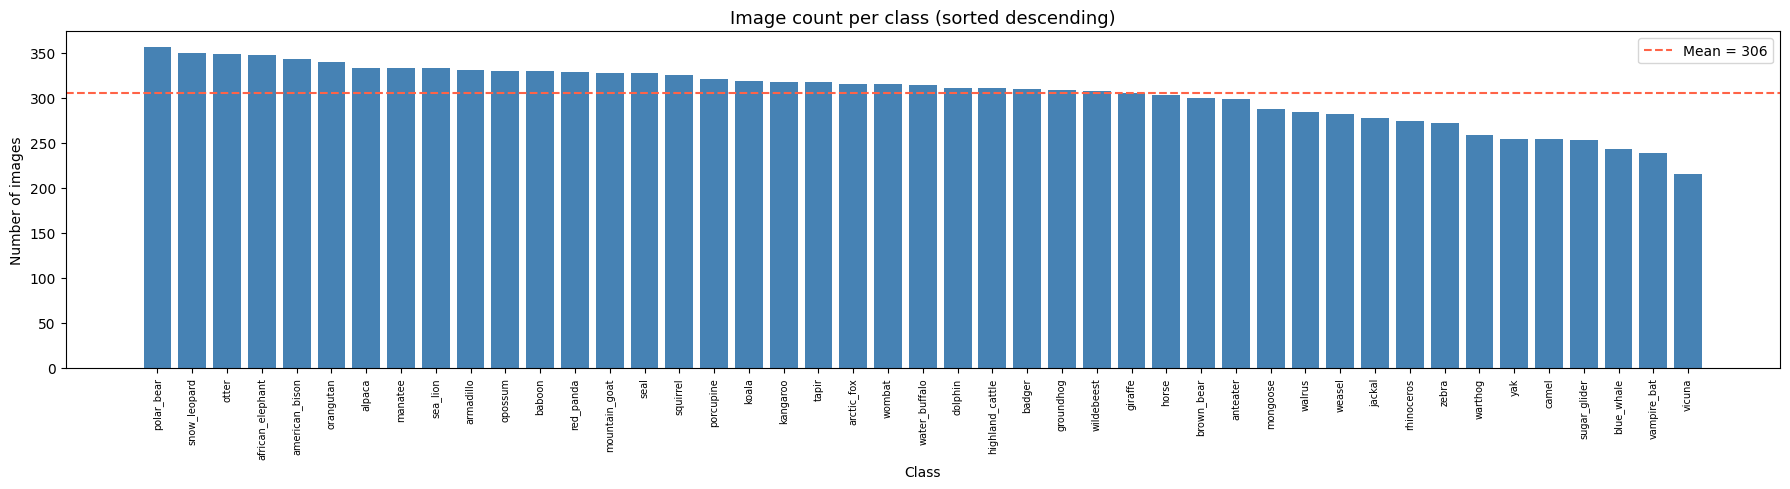

Imbalance ratio (max / min): 1.7x


In [ ]:
def plot_class_distribution(class_counts: dict) -> None:
    """
    Plot a sorted bar chart of image counts per class.

    """
    counts_series = pd.Series(class_counts).sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(18, 5))
    ax.bar(counts_series.index, counts_series.values,
           color='steelblue', edgecolor='none')
    ax.axhline(
        counts_series.mean(), color='tomato', linestyle='--', linewidth=1.5,
        label=f'Mean = {counts_series.mean():.0f}',
    )
    ax.set_title('Image count per class (sorted descending)', fontsize=13)
    ax.set_ylabel('Number of images')
    ax.set_xlabel('Class')
    ax.set_xticks(range(len(counts_series)))
    ax.set_xticklabels(counts_series.index, rotation=90, fontsize=7)
    ax.legend()
    plt.tight_layout()
    plt.show()
    imbalance_ratio = counts_series.max() / counts_series.min()
    print(f'Imbalance ratio (max / min): {imbalance_ratio:.1f}x')


# ── 1.5  Class distribution chart
plot_class_distribution(class_counts)

**EDA Observation:**
The above bar chart visually shows the class imbalance. All the classes are arranged in descending order from left to right. A naive model is the model which learns to predict the classes which has majority images more often.

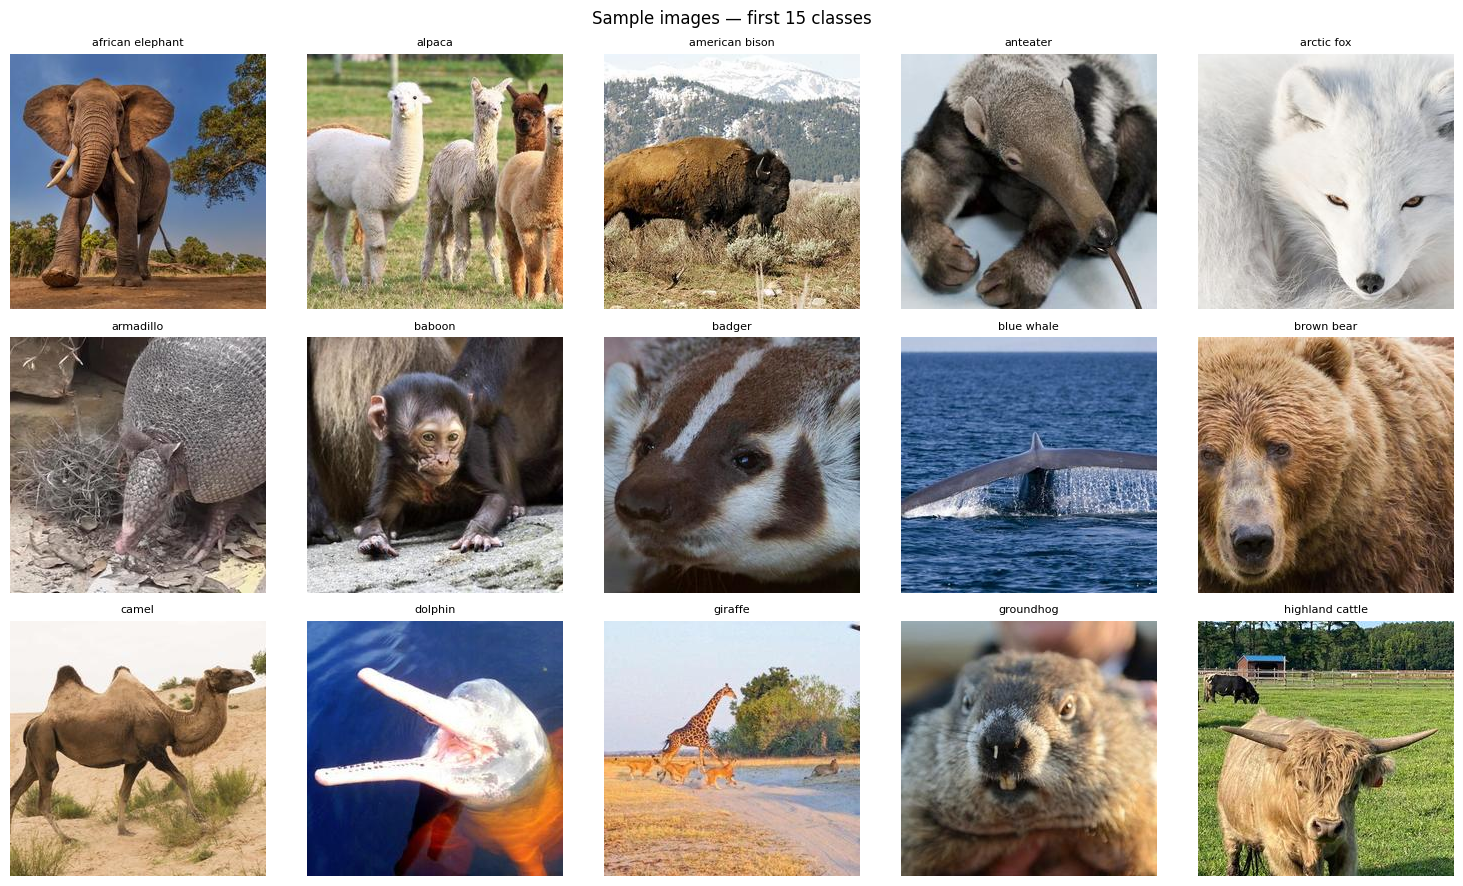

In [ ]:
def plot_sample_image_grid(class_image_map: dict, class_names: list, n_cols: int = 5) -> None:
    """
    Display a grid of one random sample image per class (first n_cols * 3 classes).

    """
    n_rows       = 3
    sample_count = n_rows * n_cols
    fig, axes    = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3))
    for ax, cls in zip(axes.flat, class_names[:sample_count]):
        try:
            img_path = random.choice(class_image_map[cls])
            img      = PIL.Image.open(img_path).convert('RGB')
            ax.imshow(img)
        except Exception:
            pass
        ax.set_title(cls.replace('_', ' '), fontsize=8)
        ax.axis('off')
    plt.suptitle('Sample images — first 15 classes', fontsize=12)
    plt.tight_layout()
    plt.show()


# ── 1.6  Sample image grid
plot_sample_image_grid(class_image_map, class_names)

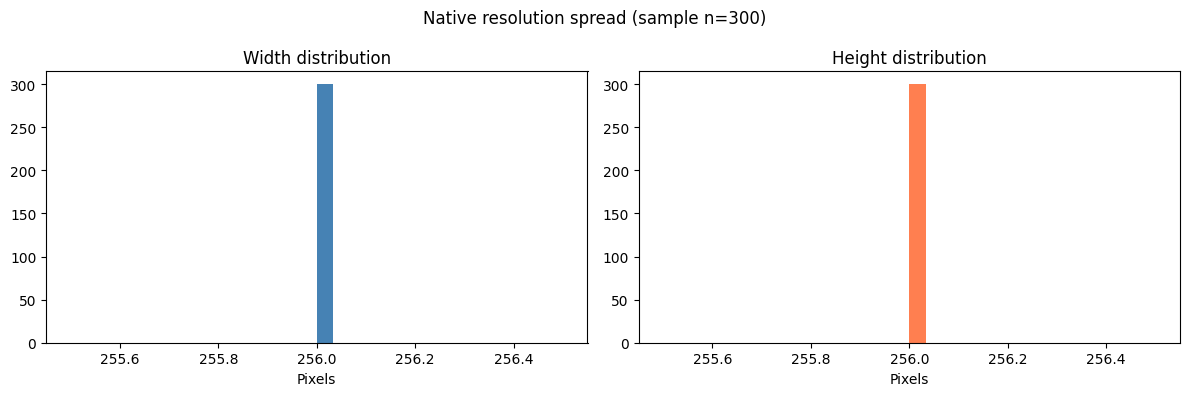

Median size: 256 x 256 px


In [ ]:
def plot_resolution_distribution(
    class_image_map: dict,
    sample_per_class: int = 7,
    max_total: int = 300,
) -> None:
    """
    Plot histograms of native image width and height for a random sample.

    """
    sampled_paths = []
    for image_files in class_image_map.values():
        sampled_paths.extend(random.sample(image_files, min(sample_per_class, len(image_files))))
    random.shuffle(sampled_paths)
    sampled_paths = sampled_paths[:max_total]

    widths, heights = [], []
    for img_path in sampled_paths:
        try:
            width, height = PIL.Image.open(img_path).size
            widths.append(width)
            heights.append(height)
        except Exception:
            pass

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(widths,  bins=30, color='steelblue', edgecolor='none')
    axes[0].set_title('Width distribution')
    axes[0].set_xlabel('Pixels')
    axes[1].hist(heights, bins=30, color='coral',     edgecolor='none')
    axes[1].set_title('Height distribution')
    axes[1].set_xlabel('Pixels')
    plt.suptitle(f'Native resolution spread (sample n={len(widths)})', fontsize=12)
    plt.tight_layout()
    plt.show()
    print(f'Median size: {np.median(widths):.0f} x {np.median(heights):.0f} px')


# ── 1.7  Resolution analysis
plot_resolution_distribution(class_image_map)

---
## Section 2 · Data Pre-Processing & Input Pipeline

### 2.1 Design decisions
- Stratified split (70/15/15): Split is the most important part when the data is imbalanced this will help to preserve class proportions.
- Normalization: It is done to [0,1] , so that the raw pixel vlaues are divided by 255 then only the gradients can be kept in numerically stable range.
- Augmentation: It is most important part for the training data because it preserves validation or test measurements by fliping, rotating or zooming the images.
- No class weight: It was not used for CNN modelling because it multiplies the loss for the minority class to 8x, causing the gradient to destabilise in a randomly initialised network causing validation loss to 18 at epoch one which i tried previously and also the training accuracy was nearly 2% at the last epoch
because keras computes it on the weighted loss.To handle the stability of imbalance data agumentation was used.


In [ ]:
# ── 2.2  Hyper-parameter configuration
# All tunable values are defined here so the entire notebook can be
# reproduced or modified by changing a single cell.

img_size_cnn    = (128, 128)   # Custom CNN input — smaller trains faster from scratch
img_size_tl     = (224, 224)   # MobileNetV2 recommended input size
batch_size      = 32           # Fits comfortably in Colab T4 GPU memory
epochs_cnn      = 60           # Upper bound; EarlyStopping decides actual stop
epochs_tl_head  = 25           # Stage 1: head-only training epochs
epochs_tl_fine  = 25           # Stage 2: fine-tuning epochs (warm-started)
lr_cnn          = 3e-4         # Lower LR — more stable for randomly-initialised CNN
lr_tl_head      = 1e-3         # Standard Adam LR for head-only stage
lr_tl_fine      = 5e-5         # Very small — prevents catastrophic forgetting
dropout_cnn     = 0.3          # Moderate dropout; no L2 on conv layers
dropout_tl      = 0.4          # Slightly higher; base model already regularises
val_split       = 0.15         # 15% validation
test_split      = 0.15         # 15% held-out test (never seen during training)
autotune        = tf.data.AUTOTUNE

In [ ]:
def build_path_label_arrays(
    class_image_map: dict,
    class_to_idx: dict,
) -> tuple:
    """
    Flatten class_image_map into parallel arrays of file paths and integer labels.

    Parameters
    ----------
    class_image_map : dict
        Mapping of class name -> list of pathlib.Path image files.
    class_to_idx : dict
        Mapping of class name -> integer class index.

    Returns
    -------
    tuple of (np.ndarray, np.ndarray)
        all_paths  : 1-D array of file path strings.
        all_labels : 1-D array of integer labels (dtype int32).
    """
    path_list  = []
    label_list = []
    for class_name, image_files in class_image_map.items():
        label_idx = class_to_idx[class_name]
        for img_path in image_files:
            path_list.append(str(img_path))
            label_list.append(label_idx)
    all_paths  = np.array(path_list)
    all_labels = np.array(label_list, dtype=np.int32)
    return all_paths, all_labels


def split_dataset(
    all_paths: np.ndarray,
    all_labels: np.ndarray,
    val_split: float,
    test_split: float,
    random_seed: int,
) -> tuple:
    """
    Perform a stratified 70 / 15 / 15 train / val / test split.

    A two-step split is used: first carve out the test set, then split
    the remainder into train and validation. Both splits use stratify=all_labels
    to ensure every class is proportionally represented in each subset.

    Parameters
    ----------
    all_paths : np.ndarray
        1-D array of file path strings.
    all_labels : np.ndarray
        1-D array of integer class labels.
    val_split : float
        Fraction of the full dataset to use for validation (e.g. 0.15).
    test_split : float
        Fraction of the full dataset to use for testing (e.g. 0.15).
    random_seed : int
        Seed for reproducible splits.

    Returns
    -------
    tuple
        (x_train, x_val, x_test, y_train, y_val, y_test) — all np.ndarray.
    """
    # Step 1: separate test set
    x_trainval, x_test, y_trainval, y_test = train_test_split(
        all_paths, all_labels,
        test_size=test_split,
        stratify=all_labels,
        random_state=random_seed,
    )
    # Step 2: split remainder into train and validation
    # Adjust val ratio relative to the remaining (trainval) portion
    adjusted_val_ratio = val_split / (1.0 - test_split)
    x_train, x_val, y_train, y_val = train_test_split(
        x_trainval, y_trainval,
        test_size=adjusted_val_ratio,
        stratify=y_trainval,
        random_state=random_seed,
    )
    return x_train, x_val, x_test, y_train, y_val, y_test


# ── 2.3  Build path/label arrays and perform stratified split
all_paths, all_labels = build_path_label_arrays(class_image_map, class_to_idx)

x_train, x_val, x_test, y_train, y_val, y_test = split_dataset(
    all_paths, all_labels,
    val_split=val_split,
    test_split=test_split,
    random_seed=SEED,
)

print(f'Train images : {len(x_train)}')
print(f'Val   images : {len(x_val)}')
print(f'Test  images : {len(x_test)}')
print(f'Total        : {len(all_paths)}')

Train images : 9625
Val   images : 2063
Test  images : 2063
Total        : 13751


In [ ]:
def build_augmentation_layer() -> keras.Sequential:
    """
    Build a Keras Sequential augmentation layer for training images.

    Applies three light transforms — horizontal flip, small rotation, and
    small zoom — chosen to diversify training examples while keeping images
    recognisable. Heavy augmentation (6+ transforms simultaneously) was
    found to make images unrecognisable, preventing learning.

    Returns
    -------
    keras.Sequential
        Augmentation pipeline. Pass training=True when calling to activate
        random operations; pass training=False (or omit) for inference.
    """
    return keras.Sequential(
        [
            layers.RandomFlip('horizontal'),         # mirror left-right
            layers.RandomRotation(0.10),             # ±10% of 2π radians
            layers.RandomZoom(0.10),                 # ±10% zoom in/out
        ],
        name='augmentation_pipeline',
    )


def make_tf_dataset(
    file_paths: np.ndarray,
    labels: np.ndarray,
    img_size: tuple,
    batch_size: int,
    augmentation_layer: keras.Sequential,
    autotune: int,
    *,
    apply_augmentation: bool = False,
    shuffle: bool = False,
    random_seed: int = 42,
) -> tf.data.Dataset:
    """
    Build a batched, pre-fetched tf.data.Dataset from file paths and labels.

    Each image is:
      1. Read from disk as raw bytes.
      2. Decoded to a uint8 RGB tensor.
      3. Cast to float32 and normalised to [0, 1].
      4. Resized to img_size using bilinear interpolation.
      5. Optionally augmented (training only).

    Parameters
    ----------
    file_paths : np.ndarray
        1-D array of absolute file path strings.
    labels : np.ndarray
        1-D array of integer class indices matching file_paths.
    img_size : tuple of (int, int)
        Target (height, width) to resize images to.
    batch_size : int
        Number of images per batch.
    augmentation_layer : keras.Sequential
        Pre-built augmentation pipeline; called only when apply_augmentation=True.
    autotune : int
        tf.data.AUTOTUNE — passed to num_parallel_calls and prefetch.
    apply_augmentation : bool, optional
        If True, apply random augmentation to each image. Default False.
    shuffle : bool, optional
        If True, shuffle the dataset before batching (use for training). Default False.
    random_seed : int, optional
        Seed for shuffle reproducibility. Default 42.

    Returns
    -------
    tf.data.Dataset
        Batched, prefetched dataset ready for model.fit().
    """
    def load_and_preprocess(file_path, label):
        """Read one image file, decode, normalise and resize."""
        raw_bytes = tf.io.read_file(file_path)
        image     = tf.image.decode_image(
            raw_bytes, channels=3, expand_animations=False
        )
        image = tf.cast(image, tf.float32) / 255.0     # normalise to [0, 1]
        image = tf.image.resize(image, img_size)        # resize to target size
        return image, label

    def apply_augment(image, label):
        """Apply random augmentation and clip back to [0, 1]."""
        image = augmentation_layer(image, training=True)
        image = tf.clip_by_value(image, 0.0, 1.0)
        return image, label

    dataset = tf.data.Dataset.from_tensor_slices(
        (tf.constant(file_paths), tf.constant(labels))
    )
    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=len(file_paths),
            seed=random_seed,
            reshuffle_each_iteration=True,
        )
    dataset = dataset.map(load_and_preprocess, num_parallel_calls=autotune)
    if apply_augmentation:
        dataset = dataset.map(apply_augment, num_parallel_calls=autotune)
    dataset = dataset.batch(batch_size).prefetch(autotune)
    return dataset


# ── 2.4  Build augmentation layer (shared by both model pipelines)
augmentation_layer = build_augmentation_layer()

In [ ]:
# ── 2.5  Build datasets for Custom CNN (128 x 128)
train_dataset_cnn = make_tf_dataset(
    x_train, y_train, img_size_cnn, batch_size,
    augmentation_layer, autotune,
    apply_augmentation=True, shuffle=True, random_seed=SEED,
)
val_dataset_cnn = make_tf_dataset(
    x_val, y_val, img_size_cnn, batch_size,
    augmentation_layer, autotune,
    apply_augmentation=False, shuffle=False,
)
test_dataset_cnn = make_tf_dataset(
    x_test, y_test, img_size_cnn, batch_size,
    augmentation_layer, autotune,
    apply_augmentation=False, shuffle=False,
)

# ── Build datasets for Transfer Learning (224 x 224)
train_dataset_tl = make_tf_dataset(
    x_train, y_train, img_size_tl, batch_size,
    augmentation_layer, autotune,
    apply_augmentation=True, shuffle=True, random_seed=SEED,
)
val_dataset_tl = make_tf_dataset(
    x_val, y_val, img_size_tl, batch_size,
    augmentation_layer, autotune,
    apply_augmentation=False, shuffle=False,
)
test_dataset_tl = make_tf_dataset(
    x_test, y_test, img_size_tl, batch_size,
    augmentation_layer, autotune,
    apply_augmentation=False, shuffle=False,
)

# ── Sanity check: verify shapes and pixel range
for images_batch, labels_batch in train_dataset_cnn.take(1):
    print(f'CNN batch shape  : {images_batch.shape}')
    print(f'Pixel range      : [{images_batch.numpy().min():.3f}, {images_batch.numpy().max():.3f}]')
for images_batch, labels_batch in train_dataset_tl.take(1):
    print(f'TL  batch shape  : {images_batch.shape}')

CNN batch shape  : (32, 128, 128, 3)
Pixel range      : [0.000, 1.000]
TL  batch shape  : (32, 224, 224, 3)


Channel      Mean      Std
----------------------------
Red        0.4966   0.2636
Green      0.4794   0.2530
Blue       0.4301   0.2639


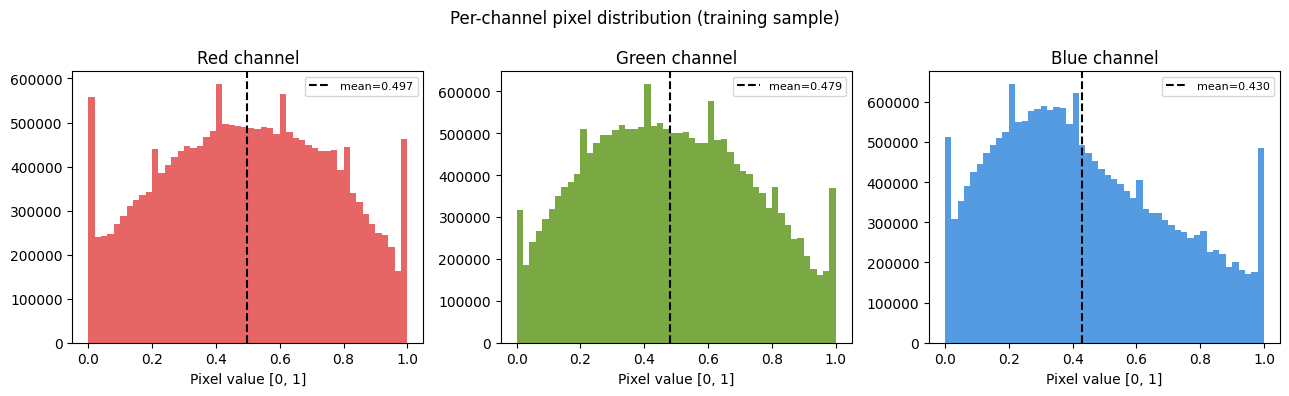

In [ ]:
def compute_channel_statistics(
    file_paths: np.ndarray,
    img_size: tuple,
    sample_size: int = 400,
    random_seed: int = 42,
) -> None:
    """
    Compute and plot per-channel pixel statistics for a training sample.

    Randomly samples sample_size images, normalises each to [0, 1], and
    prints mean and std for Red, Green, Blue channels. Also renders three
    side-by-side histograms with mean lines.

    Parameters
    ----------
    file_paths : np.ndarray
        Training file paths to sample from.
    img_size : tuple of (int, int)
        Resize target used to match the model's actual input.
    sample_size : int, optional
        Number of images to sample. Default is 400.
    random_seed : int, optional
        Seed for reproducible sampling. Default is 42.

    Returns
    -------
    None
    """
    rng          = np.random.default_rng(random_seed)
    sample_n     = min(sample_size, len(file_paths))
    sampled_idx  = rng.choice(len(file_paths), size=sample_n, replace=False)
    sample_paths = file_paths[sampled_idx]

    channel_pixels = [[], [], []]   # index 0=R, 1=G, 2=B
    for img_path in sample_paths:
        try:
            img_array = np.array(
                PIL.Image.open(img_path).convert('RGB').resize(img_size),
                dtype=np.float32,
            ) / 255.0
            for channel_idx in range(3):
                channel_pixels[channel_idx].append(img_array[:, :, channel_idx].ravel())
        except Exception:
            pass

    channel_names  = ['Red', 'Green', 'Blue']
    channel_colors = ['#E24B4A', '#639922', '#378ADD']

    print(f'{"Channel":<8} {"Mean":>8} {"Std":>8}')
    print('-' * 28)
    for channel_idx, channel_name in enumerate(channel_names):
        flat_pixels = np.concatenate(channel_pixels[channel_idx])
        print(f'{channel_name:<8} {flat_pixels.mean():>8.4f} {flat_pixels.std():>8.4f}')

    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    for channel_idx, (ax, channel_name, color) in enumerate(
        zip(axes, channel_names, channel_colors)
    ):
        flat_pixels = np.concatenate(channel_pixels[channel_idx])
        ax.hist(flat_pixels, bins=50, color=color, alpha=0.85, edgecolor='none')
        ax.axvline(
            flat_pixels.mean(), color='black', linestyle='--',
            linewidth=1.5, label=f'mean={flat_pixels.mean():.3f}',
        )
        ax.set_title(f'{channel_name} channel')
        ax.set_xlabel('Pixel value [0, 1]')
        ax.legend(fontsize=8)
    plt.suptitle('Per-channel pixel distribution (training sample)', fontsize=12)
    plt.tight_layout()
    plt.show()


# ── 2.6  Channel statistics
compute_channel_statistics(x_train, img_size_tl, sample_size=400, random_seed=SEED)

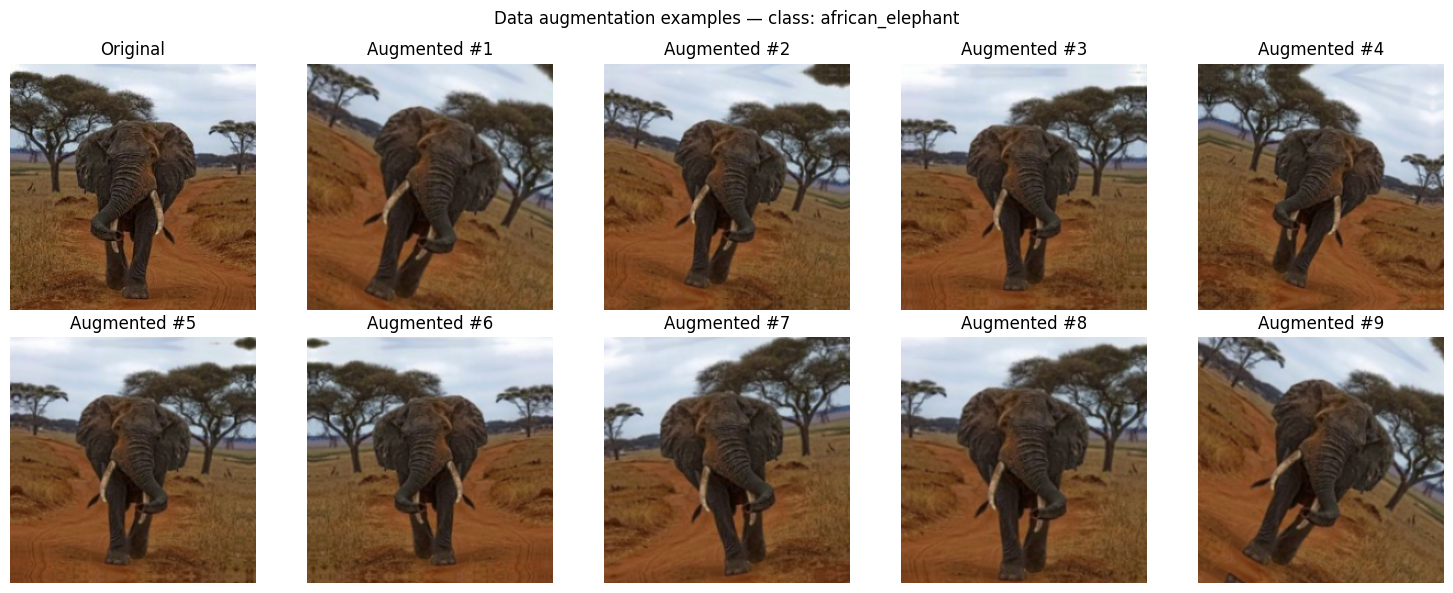

In [ ]:
def visualise_augmentation(
    class_image_map: dict,
    class_names: list,
    img_size: tuple,
    n_augmented: int = 9,
) -> None:
    """
    Display one original image alongside n_augmented random augmented versions.

    Helps verify that the augmentation is realistic — images should remain
    recognisable after transforms are applied.

    Parameters
    ----------
    class_image_map : dict
        Mapping of class name -> list of pathlib.Path files.
    class_names : list of str
        Sorted class name list; first class is used for sampling.
    img_size : tuple of (int, int)
        (height, width) to resize the original before augmenting.
    n_augmented : int, optional
        Number of augmented copies to show. Default is 9.

    Returns
    -------
    None
    """
    # Create a fresh augmentation layer instance for this visualization.
    # This ensures it's built with the correct image size for this specific call.
    local_augmentation_layer = build_augmentation_layer()

    sample_path  = str(random.choice(class_image_map[class_names[0]]))
    raw_bytes    = tf.io.read_file(sample_path)
    original_img = tf.image.decode_image(raw_bytes, channels=3, expand_animations=False)
    original_img = tf.cast(original_img, tf.float32) / 255.0
    original_img = tf.image.resize(original_img, img_size)
    original_img = tf.expand_dims(original_img, 0)   # add batch dimension

    total_slots = 1 + n_augmented
    n_cols      = 5
    n_rows      = (total_slots + n_cols - 1) // n_cols
    fig, axes   = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3))

    axes.flat[0].imshow(original_img[0].numpy())
    axes.flat[0].set_title('Original')
    axes.flat[0].axis('off')

    for slot_idx, ax in enumerate(axes.flat[1:total_slots], start=1):
        augmented = local_augmentation_layer(original_img, training=True)
        augmented = tf.clip_by_value(augmented, 0.0, 1.0)
        ax.imshow(augmented[0].numpy())
        ax.set_title(f'Augmented #{slot_idx}')
        ax.axis('off')

    for ax in axes.flat[total_slots:]:
        ax.axis('off')

    plt.suptitle(
        f'Data augmentation examples — class: {class_names[0]}', fontsize=12
    )
    plt.tight_layout()
    plt.show()


# ── 2.7  Augmentation visualisation
# Removed 'augmentation_layer' argument as the function now creates its own local instance.
visualise_augmentation(class_image_map, class_names, img_size_tl)


---
## Section 3 · Model Design in Keras

### 3.1 Model A — Custom CNN
**Architecture rationale:**
- 3 conv blocks: There are in all three filters (32,64,128). Block one which has 32 filters detects low level edges and colours. Block 2 which has 64 filters are used to capture texture and patterns. Block 3 which has 128 filters are used to detect shapes and body part arrangements.The standard practice is to double the filters after every block.
- BatchNormalization after each Conv2D: It normalizes the activation function within each mini-batch, which helps to stabilize and accelerate training by lowering internal covariate shift.
- MaxPooling2D: To reduce computation and introduce translational invariance the spatial dimensions are halved at each stage.
- GlobalAveragePooling2D instead of Flatten: Calculate the mean of each feature map, extremely reducing the parameter count by improving spatial invariance.
- Dropout: To reduce overfitting and not to suppress the gradient signal, moderate regularization is done.
- No L2 regularisation on conv layers: Redundant when BatchNormalization is used; it was discovered that adding both would excessively reduce gradients, hindering learning.
- Input size 128x128: On Colab's T4 GPU the CNN can train faster from scratch.



In [ ]:
def build_custom_cnn(
    num_classes: int,
    img_size: tuple,
    dropout_rate: float,
) -> keras.Model:
    """
    Build a three-block custom CNN for multi-class image classification.

    Architecture summary
    --------------------
    Block 1 : Conv2D(32) -> BN -> ReLU -> Conv2D(32) -> BN -> ReLU -> MaxPool -> Dropout(0.25)
    Block 2 : Conv2D(64) -> BN -> ReLU -> Conv2D(64) -> BN -> ReLU -> MaxPool -> Dropout(0.25)
    Block 3 : Conv2D(128)-> BN -> ReLU -> Conv2D(128)-> BN -> ReLU -> MaxPool -> Dropout(rate)
    Head    : GlobalAvgPool -> Dense(256) -> BN -> ReLU -> Dropout(rate) -> Dense(num_classes, softmax)

    Parameters
    ----------
    num_classes : int
        Number of output classes (45 for this dataset).
    img_size : tuple of (int, int)
        Spatial input dimensions (height, width). Channels are fixed at 3 (RGB).
    dropout_rate : float
        Dropout probability applied after Block 3 and the Dense head.

    Returns
    -------
    keras.Model
        Compiled-ready model with input shape (*img_size, 3) and softmax output.
    """
    input_layer = keras.Input(shape=(*img_size, 3), name='input_image')

    # ── Block 1: learn low-level features (edges, colours)
    x = layers.Conv2D(32, kernel_size=3, padding='same', activation='relu', name='conv1_a')(input_layer)
    x = layers.BatchNormalization(name='bn1_a')(x)
    x = layers.Conv2D(32, kernel_size=3, padding='same', activation='relu', name='conv1_b')(x)
    x = layers.BatchNormalization(name='bn1_b')(x)
    x = layers.MaxPooling2D(pool_size=2, name='pool1')(x)
    x = layers.Dropout(0.25, name='drop1')(x)

    # ── Block 2: learn mid-level features (textures, patterns)
    x = layers.Conv2D(64, kernel_size=3, padding='same', activation='relu', name='conv2_a')(x)
    x = layers.BatchNormalization(name='bn2_a')(x)
    x = layers.Conv2D(64, kernel_size=3, padding='same', activation='relu', name='conv2_b')(x)
    x = layers.BatchNormalization(name='bn2_b')(x)
    x = layers.MaxPooling2D(pool_size=2, name='pool2')(x)
    x = layers.Dropout(0.25, name='drop2')(x)

    # ── Block 3: learn high-level features (body parts, shapes)
    x = layers.Conv2D(128, kernel_size=3, padding='same', activation='relu', name='conv3_a')(x)
    x = layers.BatchNormalization(name='bn3_a')(x)
    x = layers.Conv2D(128, kernel_size=3, padding='same', activation='relu', name='conv3_b')(x)
    x = layers.BatchNormalization(name='bn3_b')(x)
    x = layers.MaxPooling2D(pool_size=2, name='pool3')(x)
    x = layers.Dropout(dropout_rate, name='drop3')(x)

    # ── Classification head
    x = layers.GlobalAveragePooling2D(name='global_avg_pool')(x)
    x = layers.Dense(256, activation='relu', name='dense_head')(x)
    x = layers.BatchNormalization(name='bn_head')(x)
    x = layers.Dropout(dropout_rate, name='drop_head')(x)
    output_layer = layers.Dense(num_classes, activation='softmax', name='predictions')(x)

    model = keras.Model(inputs=input_layer, outputs=output_layer, name='custom_cnn')
    return model


cnn_model = build_custom_cnn(num_classes, img_size_cnn, dropout_cnn)
cnn_model.summary(line_length=90)

Model: "custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                          ┃ Output Shape                 ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)              │ (None, 128, 128, 3)          │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ conv1_a (Conv2D)                      │ (None, 128, 128, 32)         │             896 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ bn1_a (BatchNormalization)            │ (None, 128, 128, 32)         │             128 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ conv1_b (Conv2D)                      │ (None, 128, 128, 32)         │           9,248 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ bn1_b (BatchNormalization)            │ (None, 128, 128, 32)         │             128 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ pool1 (MaxPooling2D)                  │ (None, 64, 64, 32)           │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ drop1 (Dropout)                       │ (None, 64, 64, 32)           │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ conv2_a (Conv2D)                      │ (None, 64, 64, 64)           │          18,496 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ bn2_a (BatchNormalization)            │ (None, 64, 64, 64)           │             256 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ conv2_b (Conv2D)                      │ (None, 64, 64, 64)           │          36,928 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ bn2_b (BatchNormalization)            │ (None, 64, 64, 64)           │             256 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ pool2 (MaxPooling2D)                  │ (None, 32, 32, 64)           │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ drop2 (Dropout)                       │ (None, 32, 32, 64)           │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ conv3_a (Conv2D)                      │ (None, 32, 32, 128)          │          73,856 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ bn3_a (BatchNormalization)            │ (None, 32, 32, 128)          │             512 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ conv3_b (Conv2D)                      │ (None, 32, 32, 128)          │         147,584 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ bn3_b (BatchNormalization)            │ (None, 32, 32, 128)          │             512 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ pool3 (MaxPooling2D)                  │ (None, 16, 16, 128)          │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ drop3 (Dropout)                       │ (None, 16, 16, 128)          │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ global_avg_pool                       │ (None, 128)                  │               0 │
│ (GlobalAveragePooling2D)              │                              │                 │
├───────────────────────────────────────┼──────────────────────────────┼───────────────

 Total params: 334,413 (1.28 MB)

 Trainable params: 333,005 (1.27 MB)

 Non-trainable params: 1,408 (5.50 KB)

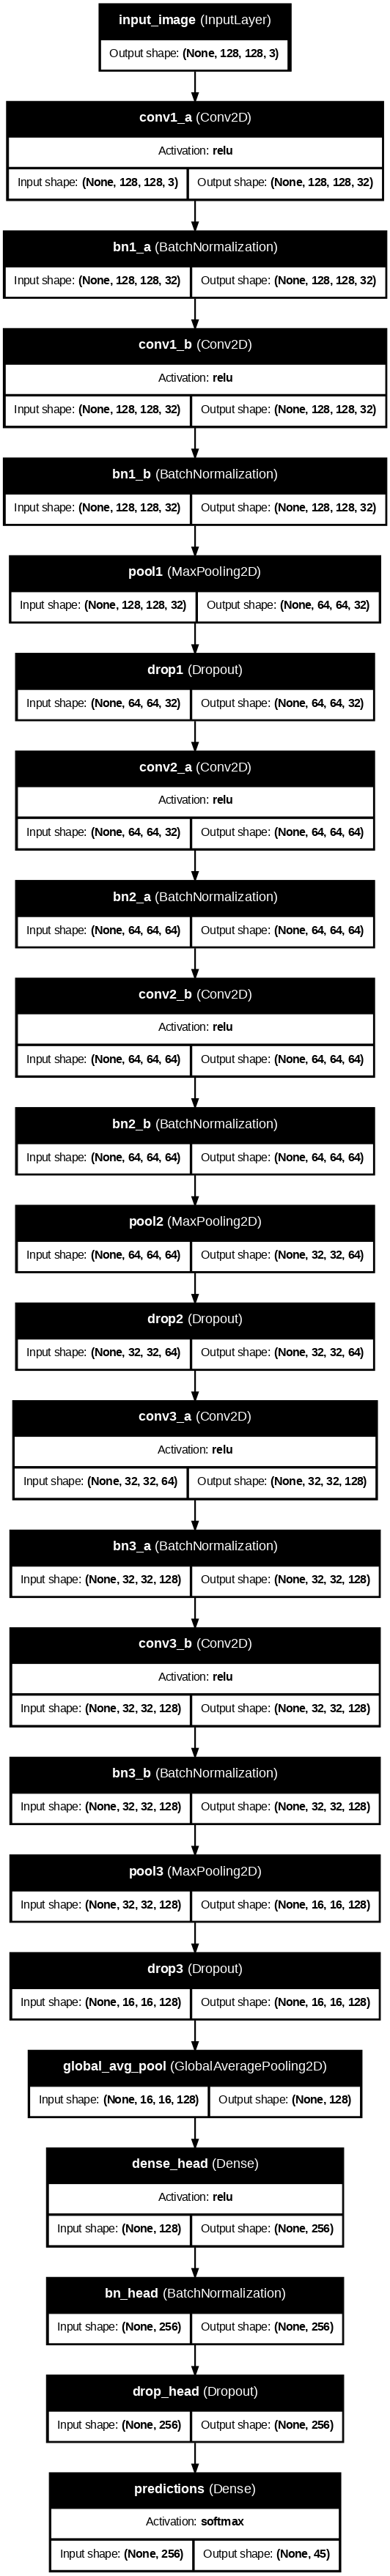

Architecture diagram saved to: cnn_architecture.png


In [ ]:
def display_model_architecture(model: keras.Model, output_filename: str) -> None:
    """
    Render and display a Keras model architecture diagram in the notebook.

    Uses keras.utils.plot_model() which requires pydot and graphviz to be
    installed. Falls back gracefully to model.summary(expand_nested=True)
    if either dependency is missing.

    Parameters
    ----------
    model : keras.Model
        The model whose architecture should be visualised.
    output_filename : str
        File name (e.g. 'cnn_architecture.png') to save the diagram to.

    Returns
    -------
    None
    """
    try:
        from tensorflow.keras.utils import plot_model
        from IPython.display import Image, display
        plot_model(
            model,
            to_file=output_filename,
            show_shapes=True,
            show_layer_names=True,
            show_layer_activations=True,
            dpi=80,
        )
        display(Image(output_filename))
        print(f'Architecture diagram saved to: {output_filename}')
    except Exception as error:
        print(f'plot_model unavailable ({error}). Falling back to summary.')
        model.summary(expand_nested=True, show_trainable=True)


# ── 3.1b  Architecture diagram — Custom CNN
display_model_architecture(cnn_model, 'cnn_architecture.png')

### 3.2 Model B — Transfer Learning with MobileNetV2
**Why MobileNetV2:**
- Pre-trained on ImageNet images, which include different animal categories its low level features are shapes, texture, body type which transfers to mammal classification.
- Its light weight and built into tf.keras.application which helps to train faster on T4 GPU.

**Two-stage training protocol:**
1. Stage 1 — head only (base frozen): The custom Dense head is trained at lr=1e-3. Before touching any base weights, it establishes a good class mapping from ImageNet features.

2. Stage 2 — fine-tune top 30 layers (base partially unfrozen): The small learning rate which is lr=5e-5 which doesnot overwrites the low-level detectors, instead of which it adapts the upper base layers to mammal specific features.

In [ ]:
def build_transfer_model(
    num_classes: int,
    img_size: tuple,
    dropout_rate: float,
) -> tuple:
    """
    Build a transfer learning model using MobileNetV2 pre-trained on ImageNet.

    The model consists of:
      - A Rescaling layer converting [0, 1] pixel values to [-1, 1] as
        required by MobileNetV2's pre-processing.
      - The MobileNetV2 base (frozen by default for Stage 1 training).
      - A custom classification head: GlobalAvgPool -> Dense(256, relu) ->
        BatchNorm -> Dropout -> Dense(num_classes, softmax).

    Parameters
    ----------
    num_classes : int
        Number of output classes.
    img_size : tuple of (int, int)
        Spatial input dimensions; must be (224, 224) for MobileNetV2.
    dropout_rate : float
        Dropout probability applied before the final Dense layer.

    Returns
    -------
    tuple of (keras.Model, keras.Model)
        full_model  : The complete model with input and output layers.
        base_model  : The MobileNetV2 sub-model (returned separately so its
                      layers can be selectively unfrozen in Stage 2).
    """
    input_layer = keras.Input(shape=(*img_size, 3), name='input_image')

    # MobileNetV2 expects pixel values in [-1, 1]; rescale from [0, 1]
    rescaled = layers.Rescaling(
        scale=2.0, offset=-1.0, name='rescale_to_mobilenet'
    )(input_layer)

    # Load pre-trained MobileNetV2 without its original top classifier
    base_model = MobileNetV2(
        input_shape=(*img_size, 3),
        include_top=False,
        weights='imagenet',
    )
    base_model.trainable = False   # frozen during Stage 1

    # Pass training=False so BatchNorm layers inside MobileNetV2 use
    # their stored running statistics (inference mode) even during Stage 1.
    feature_maps  = base_model(rescaled, training=False)

    # Custom classification head
    x = layers.GlobalAveragePooling2D(name='global_avg_pool')(feature_maps)
    x = layers.Dense(256, activation='relu', name='dense_head')(x)
    x = layers.BatchNormalization(name='bn_head')(x)
    x = layers.Dropout(dropout_rate, name='drop_head')(x)
    output_layer = layers.Dense(num_classes, activation='softmax', name='predictions')(x)

    full_model = keras.Model(
        inputs=input_layer, outputs=output_layer, name='mobilenetv2_transfer'
    )
    return full_model, base_model


tl_model, base_model = build_transfer_model(num_classes, img_size_tl, dropout_tl)
tl_model.summary(line_length=90)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "mobilenetv2_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                          ┃ Output Shape                 ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)              │ (None, 224, 224, 3)          │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ rescale_to_mobilenet (Rescaling)      │ (None, 224, 224, 3)          │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)     │ (None, 7, 7, 1280)           │       2,257,984 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ global_avg_pool                       │ (None, 1280)                 │               0 │
│ (GlobalAveragePooling2D)              │                              │                 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ dense_head (Dense)                    │ (None, 256)                  │         327,936 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ bn_head (BatchNormalization)          │ (None, 256)                  │           1,024 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ drop_head (Dropout)                   │ (None, 256)                  │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ predictions (Dense)                   │ (None, 45)                   │          11,565 │
└───────────────────────────────────────┴──────────────────────────────┴─────────────────┘

 Total params: 2,598,509 (9.91 MB)

 Trainable params: 340,013 (1.30 MB)

 Non-trainable params: 2,258,496 (8.62 MB)

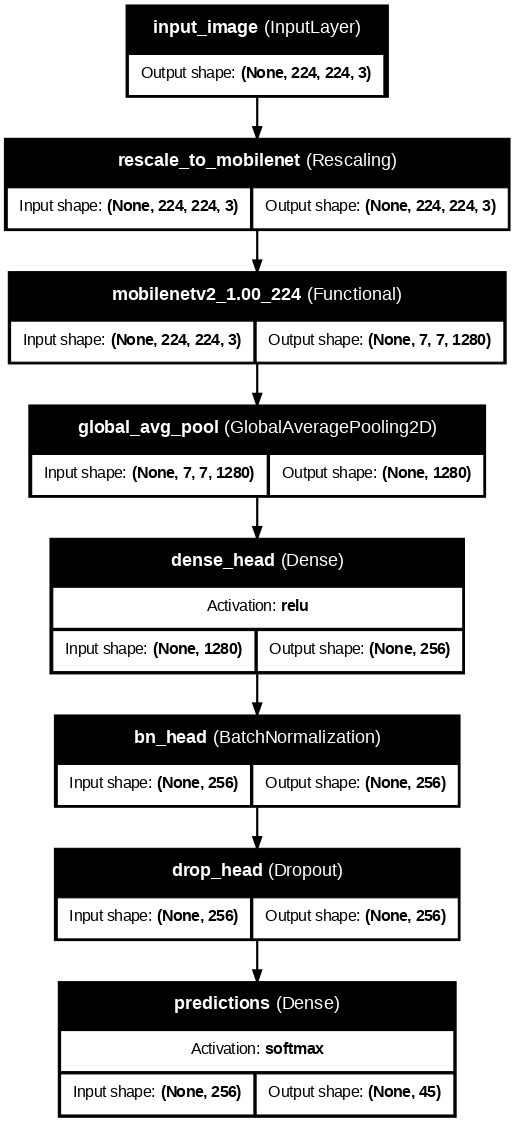

Architecture diagram saved to: tl_architecture.png


In [ ]:
# ── 3.2b  Architecture diagram — MobileNetV2 Transfer Learning model
display_model_architecture(tl_model, 'tl_architecture.png')

---
## Section 4 · Model(s) Training & Callbacks

### 4.1 Callbacks — rationale
- ModelCheckpoint (`monitor='val_accuracy'`): During the training phase it saves the best weights which helps to ensure the final model is the best model  and not the last epoch.
- EarlyStopping (`patience=15`, `restore_best_weights=True`): It stops training when the val_accuracy doesnot improve for 15 cosecutive epochs and reverts to the best checkpoint.
- ReduceLROnPlateau (`patience=5`, `factor=0.5`):allows for sharper gradient steps when nearing a minimum by halving the learning rate when val_loss plateaus for five epochs.
- TensorBoard: For interactive inspection of logs that are trained on per epoch.


In [ ]:
def build_callbacks(
    checkpoint_path: str,
    early_stopping_patience: int = 15,
    reduce_lr_patience: int = 5,
    monitor_metric: str = 'val_accuracy',
    monitor_mode: str = 'max',
) -> list:
    """
    Build a list of standard Keras training callbacks.

    Parameters
    ----------
    checkpoint_path : str
        File path to save the best model weights (e.g. 'best_cnn.keras').
    early_stopping_patience : int, optional
        Number of epochs with no improvement before stopping. Default 15.
    reduce_lr_patience : int, optional
        Number of epochs with no val_loss improvement before halving LR. Default 5.
    monitor_metric : str, optional
        Metric name to monitor for ModelCheckpoint and EarlyStopping. Default 'val_accuracy'.
    monitor_mode : str, optional
        'max' if higher is better (accuracy), 'min' if lower is better (loss). Default 'max'.

    Returns
    -------
    list of keras.callbacks.Callback
        [ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, TensorBoard]
    """
    model_checkpoint = callbacks.ModelCheckpoint(
        filepath=checkpoint_path,
        monitor=monitor_metric,
        save_best_only=True,
        mode=monitor_mode,
        verbose=1,
    )
    early_stopping = callbacks.EarlyStopping(
        monitor=monitor_metric,
        patience=early_stopping_patience,
        restore_best_weights=True,
        mode=monitor_mode,
        verbose=1,
    )
    reduce_lr = callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=reduce_lr_patience,
        min_lr=1e-7,
        verbose=1,
    )
    tensorboard = callbacks.TensorBoard(
        log_dir=f'./logs/{checkpoint_path.replace(".keras", "")}'
    )
    return [model_checkpoint, early_stopping, reduce_lr, tensorboard]


def plot_training_history(history: keras.callbacks.History, title: str = 'Training') -> None:
    """
    Plot accuracy and loss curves from a Keras History object.

    Renders two side-by-side line charts:
      - Left:  training and validation accuracy per epoch.
      - Right: training and validation loss per epoch.

    Parameters
    ----------
    history : keras.callbacks.History
        The object returned by model.fit().
    title : str, optional
        Title prefix for both subplots. Default is 'Training'.

    Returns
    -------
    None
    """
    epoch_range = range(1, len(history.history['accuracy']) + 1)
    fig, axes   = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(epoch_range, history.history['accuracy'],     label='train', color='steelblue')
    axes[0].plot(epoch_range, history.history['val_accuracy'], label='val',   color='coral')
    axes[0].set_title(f'{title} — Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(epoch_range, history.history['loss'],     label='train', color='steelblue')
    axes[1].plot(epoch_range, history.history['val_loss'], label='val',   color='coral')
    axes[1].set_title(f'{title} — Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

### 4.2 Train Custom CNN

In [ ]:
# Compile the Custom CNN
# Adam at lr=3e-4 is more stable for randomly-initialised CNNs than the default 1e-3.
# sparse_categorical_crossentropy is used because labels are integer indices, not one-hot.
# class_weight is intentionally omitted — see Section 2.1 rationale.
cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr_cnn),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

cnn_callbacks = build_callbacks(
    checkpoint_path='best_cnn.keras',
    early_stopping_patience=15,
    reduce_lr_patience=5,
)

print('=== Training Custom CNN ===')
history_cnn = cnn_model.fit(
    train_dataset_cnn,
    validation_data=val_dataset_cnn,
    epochs=epochs_cnn,
    callbacks=cnn_callbacks,
    verbose=1,
)

=== Training Custom CNN ===
Epoch 1/60
301/301 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step - accuracy: 0.0812 - loss: 3.9226
Epoch 1: val_accuracy improved from None to 0.04653, saving model to best_cnn.keras

Epoch 1: finished saving model to best_cnn.keras
301/301 ━━━━━━━━━━━━━━━━━━━━ 126s 352ms/step - accuracy: 0.1042 - loss: 3.7137 - val_accuracy: 0.0465 - val_loss: 4.1871 - learning_rate: 3.0000e-04
Epoch 2/60
301/301 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.1444 - loss: 3.4133
Epoch 2: val_accuracy improved from 0.04653 to 0.15172, saving model to best_cnn.keras

Epoch 2: finished saving model to best_cnn.keras
301/301 ━━━━━━━━━━━━━━━━━━━━ 58s 191ms/step - accuracy: 0.1532 - loss: 3.3630 - val_accuracy: 0.1517 - val_loss: 3.3508 - learning_rate: 3.0000e-04
Epoch 3/60
301/301 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.1744 - loss: 3.2110
Epoch 3: val_accuracy did not improve from 0.15172
301/301 ━━━━━━━━━━━━━━━━━━━━ 57s 189ms/step - accuracy: 0.1863 - loss: 3.1568 - val_accur

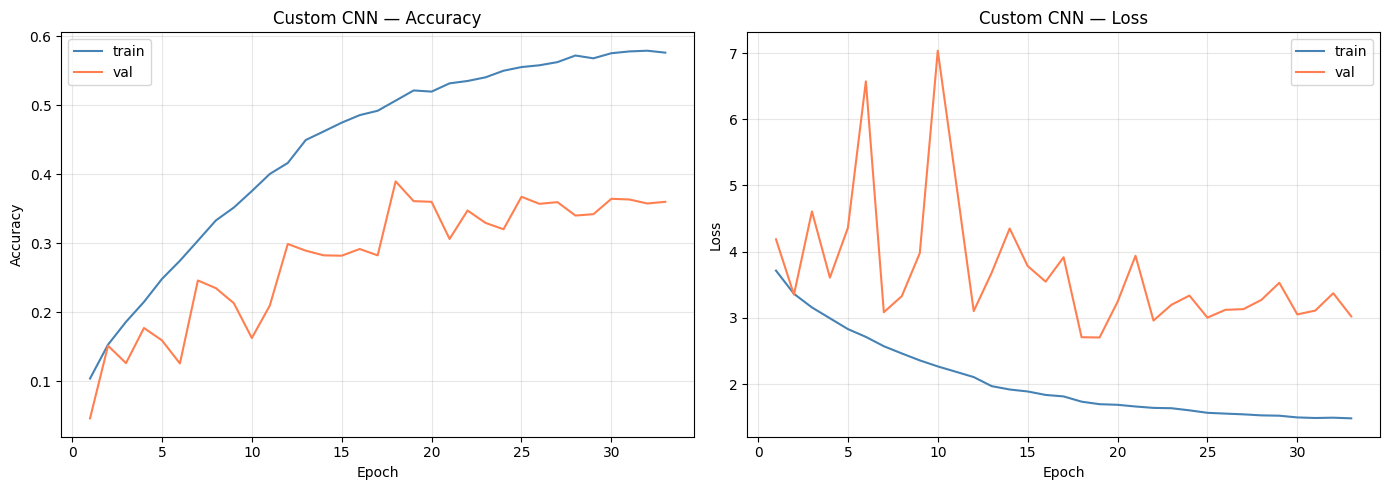

In [ ]:
plot_training_history(history_cnn, title='Custom CNN')

**Training curve interpretation:** A Good fit training curve shows validation accuracy increasing steadily and ending close to training accuracy. But in the above graph we can see that there is a large gap between both which indicates overfitting -mitigated here by Dropout and EarlyStopping.

### 4.3 Overfitting Detection

In [ ]:
def detect_overfitting(
    history: keras.callbacks.History,
    model_name: str,
    overfitting_threshold: float = 0.10,
) -> float:
    """
    Compute the train-val accuracy gap and flag overfitting or underfitting.

    A gap (train_acc - val_acc) greater than overfitting_threshold is flagged
    as overfitting. A negative gap (val > train) is flagged as unusual and may
    indicate overly aggressive augmentation.

    Parameters
    ----------
    history : keras.callbacks.History
        Object returned by model.fit().
    model_name : str
        Label printed in the diagnostic output.
    overfitting_threshold : float, optional
        Maximum acceptable gap before flagging overfitting. Default is 0.10.

    Returns
    -------
    float
        The computed accuracy gap (train_acc - val_acc) at the final epoch.
    """
    final_train_acc = history.history['accuracy'][-1]
    final_val_acc   = history.history['val_accuracy'][-1]
    best_val_acc    = max(history.history['val_accuracy'])
    accuracy_gap    = final_train_acc - final_val_acc

    print(f'\n── {model_name} ──')
    print(f'  Best val accuracy  : {best_val_acc:.4f}')
    print(f'  Final train acc    : {final_train_acc:.4f}')
    print(f'  Final val acc      : {final_val_acc:.4f}')
    print(f'  Gap (train - val)  : {accuracy_gap:.4f}  ', end='')

    if accuracy_gap > overfitting_threshold:
        print('WARNING: OVERFITTING detected')
    elif accuracy_gap < -0.02:
        print('CHECK: val > train (augmentation may be too strong)')
    else:
        print('GOOD FIT')

    return accuracy_gap


detect_overfitting(history_cnn, model_name='Custom CNN')


── Custom CNN ──
  Best val accuracy  : 0.3897
  Final train acc    : 0.5762
  Final val acc      : 0.3602
  Gap (train - val)  : 0.2161  WARNING: OVERFITTING detected


0.21605271100997925

### 4.4 Transfer Learning — Stage 1 (head only, base frozen)

=== Transfer Learning — Stage 1: head only ===
Epoch 1/25
301/301 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step - accuracy: 0.5901 - loss: 1.6657
Epoch 1: val_accuracy improved from None to 0.88851, saving model to best_tl_stage1.keras

Epoch 1: finished saving model to best_tl_stage1.keras
301/301 ━━━━━━━━━━━━━━━━━━━━ 148s 425ms/step - accuracy: 0.7431 - loss: 0.9723 - val_accuracy: 0.8885 - val_loss: 0.3800 - learning_rate: 0.0010
Epoch 2/25
301/301 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step - accuracy: 0.8707 - loss: 0.4586
Epoch 2: val_accuracy improved from 0.88851 to 0.90548, saving model to best_tl_stage1.keras

Epoch 2: finished saving model to best_tl_stage1.keras
301/301 ━━━━━━━━━━━━━━━━━━━━ 101s 335ms/step - accuracy: 0.8677 - loss: 0.4550 - val_accuracy: 0.9055 - val_loss: 0.3232 - learning_rate: 0.0010
Epoch 3/25
301/301 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step - accuracy: 0.8839 - loss: 0.3912
Epoch 3: val_accuracy improved from 0.90548 to 0.91178, saving model to best_tl_stage1.keras

Epoch 3: f

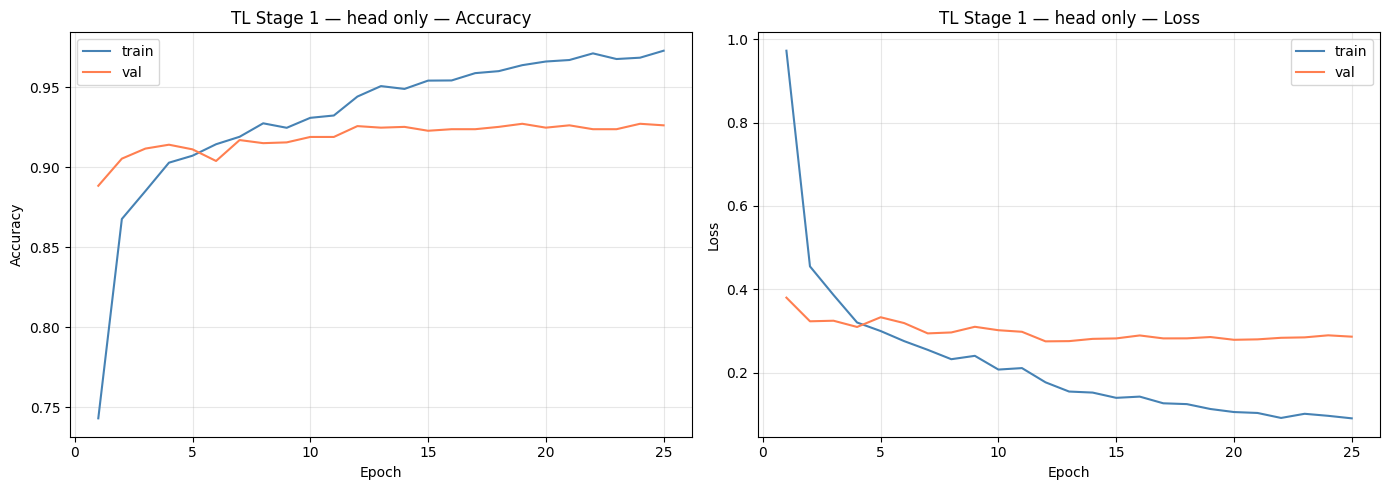


── TL Stage 1 ──
  Best val accuracy  : 0.9273
  Final train acc    : 0.9730
  Final val acc      : 0.9263
  Gap (train - val)  : 0.0467  GOOD FIT


0.046666085720062256

In [ ]:
# Stage 1: only the Dense head trains; MobileNetV2 base stays fully frozen.
# This establishes a good class mapping from ImageNet features before any
# base weights are modified.
tl_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr_tl_head),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

stage1_callbacks = build_callbacks(
    checkpoint_path='best_tl_stage1.keras',
    early_stopping_patience=10,
    reduce_lr_patience=4,
)

print('=== Transfer Learning — Stage 1: head only ===')
history_tl_stage1 = tl_model.fit(
    train_dataset_tl,
    validation_data=val_dataset_tl,
    epochs=epochs_tl_head,
    callbacks=stage1_callbacks,
    verbose=1,
)

plot_training_history(history_tl_stage1, title='TL Stage 1 — head only')
detect_overfitting(history_tl_stage1, model_name='TL Stage 1')

### 4.5 Transfer Learning — Stage 2 (fine-tune top 30 layers)

Loaded best Stage 1 weights (val_accuracy = 0.9273)
Base model total layers    : 154
Trainable after unfreeze   : 30
Frozen layers              : 124

=== Transfer Learning — Stage 2: fine-tuning ===
Epoch 1/25
301/301 ━━━━━━━━━━━━━━━━━━━━ 0s 362ms/step - accuracy: 0.8858 - loss: 0.3635
Epoch 1: val_accuracy improved from None to 0.91614, saving model to best_tl_stage2.keras

Epoch 1: finished saving model to best_tl_stage2.keras
301/301 ━━━━━━━━━━━━━━━━━━━━ 138s 399ms/step - accuracy: 0.8985 - loss: 0.3247 - val_accuracy: 0.9161 - val_loss: 0.3535 - learning_rate: 5.0000e-05
Epoch 2/25
301/301 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step - accuracy: 0.9274 - loss: 0.2240
Epoch 2: val_accuracy improved from 0.91614 to 0.92293, saving model to best_tl_stage2.keras

Epoch 2: finished saving model to best_tl_stage2.keras
301/301 ━━━━━━━━━━━━━━━━━━━━ 118s 348ms/step - accuracy: 0.9315 - loss: 0.2113 - val_accuracy: 0.9229 - val_loss: 0.3253 - learning_rate: 5.0000e-05
Epoch 3/25
301/301 ━━━━━━━━━━━━

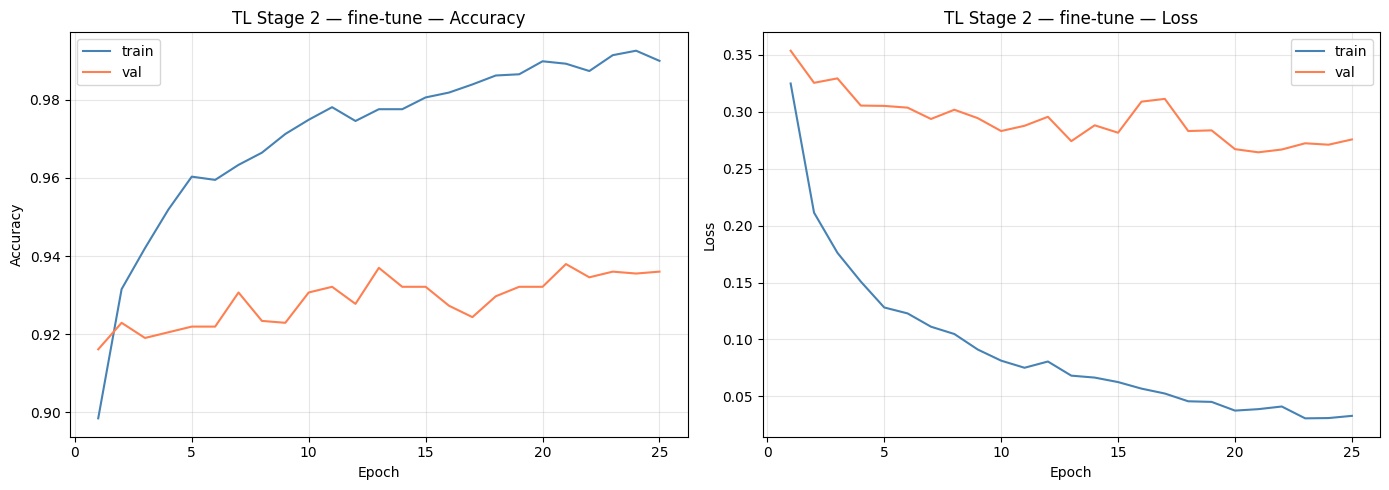


── TL Stage 2 ──
  Best val accuracy  : 0.9380
  Final train acc    : 0.9899
  Final val acc      : 0.9360
  Gap (train - val)  : 0.0539  GOOD FIT


0.05390661954879761

In [ ]:
def unfreeze_top_layers(base_model: keras.Model, num_layers_to_unfreeze: int) -> None:
    """
    Unfreeze the top N layers of a frozen base model for fine-tuning.

    All layers before the top N remain frozen to preserve low-level
    features (edges, textures) learned from ImageNet. Only the upper
    layers — which encode more task-specific, high-level representations —
    are allowed to update during fine-tuning.

    Parameters
    ----------
    base_model : keras.Model
        The pre-trained backbone sub-model (e.g. MobileNetV2).
    num_layers_to_unfreeze : int
        Number of layers from the top of the base to make trainable.

    Returns
    -------
    None
        Modifies base_model.layers[*].trainable in-place.
    """
    base_model.trainable = True
    freeze_up_to_idx = len(base_model.layers) - num_layers_to_unfreeze
    for layer in base_model.layers[:freeze_up_to_idx]:
        layer.trainable = False
    trainable_count = sum(1 for layer in base_model.layers if layer.trainable)
    print(f'Base model total layers    : {len(base_model.layers)}')
    print(f'Trainable after unfreeze   : {trainable_count}')
    print(f'Frozen layers              : {len(base_model.layers) - trainable_count}')


# ── CRITICAL: Load the BEST Stage 1 weights before starting Stage 2.
# EarlyStopping restores best weights only when it fires. If training ran
# all epochs, the model holds the final-epoch weights (not the best epoch).
# Explicitly loading the checkpoint guarantees Stage 2 starts from the
# best Stage 1 checkpoint — preventing immediate accuracy collapse.
tl_model.load_weights('best_tl_stage1.keras')
best_stage1_val_acc = max(history_tl_stage1.history['val_accuracy'])
print(f'Loaded best Stage 1 weights (val_accuracy = {best_stage1_val_acc:.4f})')

# Unfreeze top 30 layers (safer than 40 — lower risk of catastrophic forgetting)
unfreeze_top_layers(base_model, num_layers_to_unfreeze=30)

# Recompile with a very small learning rate — essential for fine-tuning.
# A large LR here would overwrite pre-trained weights and degrade performance.
tl_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr_tl_fine),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

stage2_callbacks = build_callbacks(
    checkpoint_path='best_tl_stage2.keras',
    early_stopping_patience=10,
    reduce_lr_patience=4,
)

print('\n=== Transfer Learning — Stage 2: fine-tuning ===')
history_tl_stage2 = tl_model.fit(
    train_dataset_tl,
    validation_data=val_dataset_tl,
    epochs=epochs_tl_fine,
    callbacks=stage2_callbacks,
    verbose=1,
)

plot_training_history(history_tl_stage2, title='TL Stage 2 — fine-tune')
detect_overfitting(history_tl_stage2, model_name='TL Stage 2')

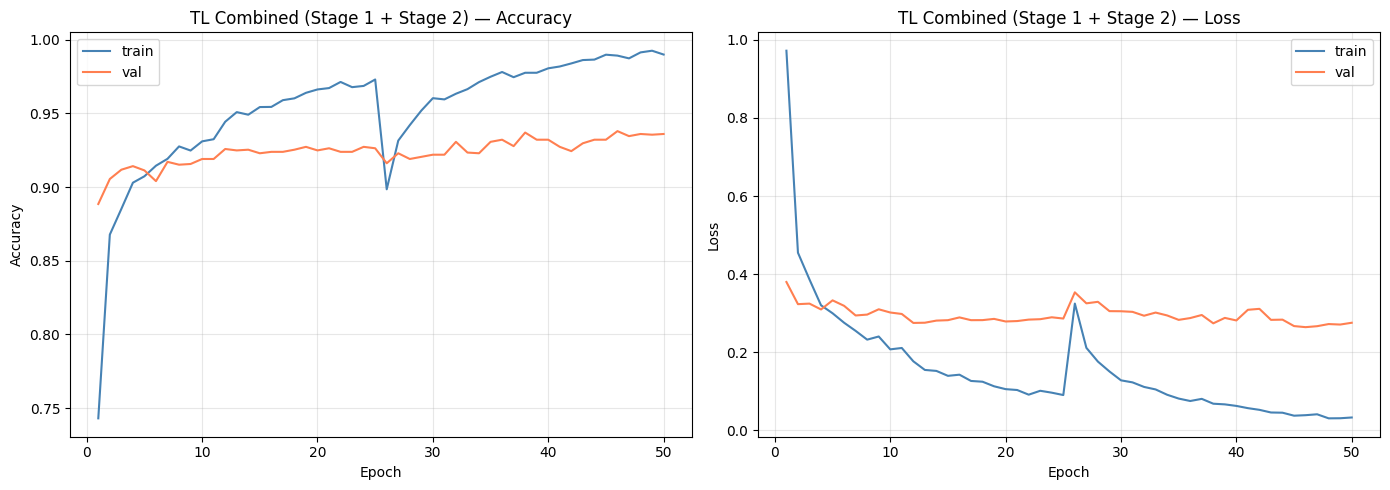

In [ ]:
def merge_training_histories(
    history_stage1: keras.callbacks.History,
    history_stage2: keras.callbacks.History,
) -> object:
    """
    Concatenate two Keras History objects into one for combined plotting.

    Each metric list from stage 1 is concatenated with the matching list
    from stage 2. The result is a lightweight object with a .history dict
    compatible with plot_training_history().

    Parameters
    ----------
    history_stage1 : keras.callbacks.History
        History object from Stage 1 training.
    history_stage2 : keras.callbacks.History
        History object from Stage 2 training.

    Returns
    -------
    object
        Lightweight object with a .history attribute (dict of merged lists).
    """
    merged_dict = {}
    for metric_key in history_stage1.history:
        merged_dict[metric_key] = (
            history_stage1.history[metric_key]
            + history_stage2.history.get(metric_key, [])
        )

    class CombinedHistory:
        """Minimal container mimicking keras.callbacks.History for plotting."""
        def __init__(self, history_dict: dict):
            self.history = history_dict

    return CombinedHistory(merged_dict)


# ── Combined curve (Stage 1 + Stage 2)
combined_tl_history = merge_training_histories(history_tl_stage1, history_tl_stage2)
plot_training_history(combined_tl_history, title='TL Combined (Stage 1 + Stage 2)')

---
## Section 5 · Model(s) Evaluation and Error Analysis

In [ ]:
def collect_predictions(
    model: keras.Model,
    dataset: tf.data.Dataset,
) -> tuple:
    """
    Run inference on a tf.data.Dataset and collect ground-truth and predicted labels.

    Parameters
    ----------
    model : keras.Model
        Trained model to evaluate.
    dataset : tf.data.Dataset
        Batched dataset yielding (images, labels) tuples.
        Must NOT have augmentation applied.

    Returns
    -------
    tuple of (np.ndarray, np.ndarray)
        y_true : 1-D array of ground-truth integer labels.
        y_pred : 1-D array of predicted integer labels (argmax of softmax output).
    """
    y_true_list = []
    y_pred_list = []
    for image_batch, label_batch in dataset:
        softmax_probs = model.predict(image_batch, verbose=0)
        predicted_ids = np.argmax(softmax_probs, axis=1)
        y_true_list.extend(label_batch.numpy().tolist())
        y_pred_list.extend(predicted_ids.tolist())
    return np.array(y_true_list), np.array(y_pred_list)


# ── 5.1  Collect predictions on the held-out test set
print('Running CNN inference on test set...')
y_true, y_pred_cnn = collect_predictions(cnn_model, test_dataset_cnn)

print('Running TL inference on test set...')
_,      y_pred_tl  = collect_predictions(tl_model,  test_dataset_tl)

print('Inference complete.')

Running CNN inference on test set...
Running TL inference on test set...
Inference complete.


In [ ]:
def compute_and_print_metrics(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    model_name: str,
) -> dict:
    """
    Compute and print Top-1 accuracy, macro F1, precision and recall.

    All averages are macro — each class is weighted equally regardless
    of its sample count, making this more informative under class imbalance.

    Parameters
    ----------
    y_true : np.ndarray
        Ground-truth integer labels.
    y_pred : np.ndarray
        Predicted integer labels.
    model_name : str
        Label printed in the output.

    Returns
    -------
    dict
        Keys: 'model', 'accuracy', 'macro_f1', 'precision', 'recall'.
    """
    top1_accuracy   = accuracy_score(y_true, y_pred)
    macro_f1        = f1_score(y_true, y_pred, average='macro', zero_division=0)
    macro_precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
    macro_recall    = recall_score(y_true, y_pred, average='macro', zero_division=0)

    print(f'\n── {model_name} ──')
    print(f'  Top-1 Accuracy  : {top1_accuracy:.4f}  ({top1_accuracy * 100:.1f}%)')
    print(f'  Macro F1-score  : {macro_f1:.4f}')
    print(f'  Macro Precision : {macro_precision:.4f}')
    print(f'  Macro Recall    : {macro_recall:.4f}')

    return {
        'model'    : model_name,
        'accuracy' : top1_accuracy,
        'macro_f1' : macro_f1,
        'precision': macro_precision,
        'recall'   : macro_recall,
    }


# ── 5.2  Scalar metrics
metrics_cnn = compute_and_print_metrics(y_true, y_pred_cnn, 'Custom CNN')
metrics_tl  = compute_and_print_metrics(y_true, y_pred_tl,  'MobileNetV2 TL')

metrics_summary_df = pd.DataFrame([metrics_cnn, metrics_tl]).set_index('model')
print('\n', metrics_summary_df.round(4).to_string())


── Custom CNN ──
  Top-1 Accuracy  : 0.3597  (36.0%)
  Macro F1-score  : 0.3446
  Macro Precision : 0.4339
  Macro Recall    : 0.3546

── MobileNetV2 TL ──
  Top-1 Accuracy  : 0.9370  (93.7%)
  Macro F1-score  : 0.9356
  Macro Precision : 0.9392
  Macro Recall    : 0.9349

                 accuracy  macro_f1  precision  recall
model                                                
Custom CNN        0.3597    0.3446     0.4339  0.3546
MobileNetV2 TL    0.9370    0.9356     0.9392  0.9349


In [ ]:
def compute_top5_accuracy(
    model: keras.Model,
    dataset: tf.data.Dataset,
    k: int = 5,
) -> float:
    """
    Compute Top-K accuracy using TensorFlow's built-in metric.

    Top-K accuracy checks whether the true label appears among the K
    highest-probability predictions. For a 45-class problem this is a
    useful supplementary metric alongside Top-1 accuracy.

    Parameters
    ----------
    model : keras.Model
        Trained model with softmax output.
    dataset : tf.data.Dataset
        Batched, un-augmented dataset yielding (images, labels).
    k : int, optional
        Number of top predictions to consider. Default is 5.

    Returns
    -------
    float
        Top-K accuracy in [0, 1].
    """
    top_k_metric = tf.keras.metrics.SparseTopKCategoricalAccuracy(k=k)
    for image_batch, label_batch in dataset:
        softmax_probs = model.predict(image_batch, verbose=0)
        top_k_metric.update_state(label_batch, softmax_probs)
    return float(top_k_metric.result().numpy())


# ── 5.2b  Top-5 accuracy
top5_cnn = compute_top5_accuracy(cnn_model, test_dataset_cnn, k=5)
top5_tl  = compute_top5_accuracy(tl_model,  test_dataset_tl,  k=5)
print(f'Top-5 Accuracy — Custom CNN     : {top5_cnn:.4f} ({top5_cnn * 100:.1f}%)')
print(f'Top-5 Accuracy — MobileNetV2 TL : {top5_tl:.4f} ({top5_tl * 100:.1f}%)')

Top-5 Accuracy — Custom CNN     : 0.6893 (68.9%)
Top-5 Accuracy — MobileNetV2 TL : 0.9898 (99.0%)


In [ ]:
# ── 5.3  Full per-class classification report
print('=== MobileNetV2 TL — Classification Report ===')
print(classification_report(
    y_true, y_pred_tl,
    target_names=class_names,
    zero_division=0,
))
print('\n=== Custom CNN — Classification Report ===')
print(classification_report(
    y_true, y_pred_cnn,
    target_names=class_names,
    zero_division=0,
))

=== MobileNetV2 TL — Classification Report ===
                  precision    recall  f1-score   support

african_elephant       0.98      1.00      0.99        52
          alpaca       0.83      0.96      0.89        50
  american_bison       0.92      0.96      0.94        51
        anteater       0.85      0.98      0.91        45
      arctic_fox       1.00      0.96      0.98        47
       armadillo       0.98      0.96      0.97        50
          baboon       0.98      0.96      0.97        50
          badger       1.00      0.85      0.92        46
      blue_whale       0.81      0.94      0.87        36
      brown_bear       1.00      0.96      0.98        45
           camel       0.95      1.00      0.97        38
         dolphin       0.98      0.85      0.91        47
         giraffe       0.98      1.00      0.99        46
       groundhog       0.96      0.93      0.95        46
 highland_cattle       0.91      0.89      0.90        47
           horse       0

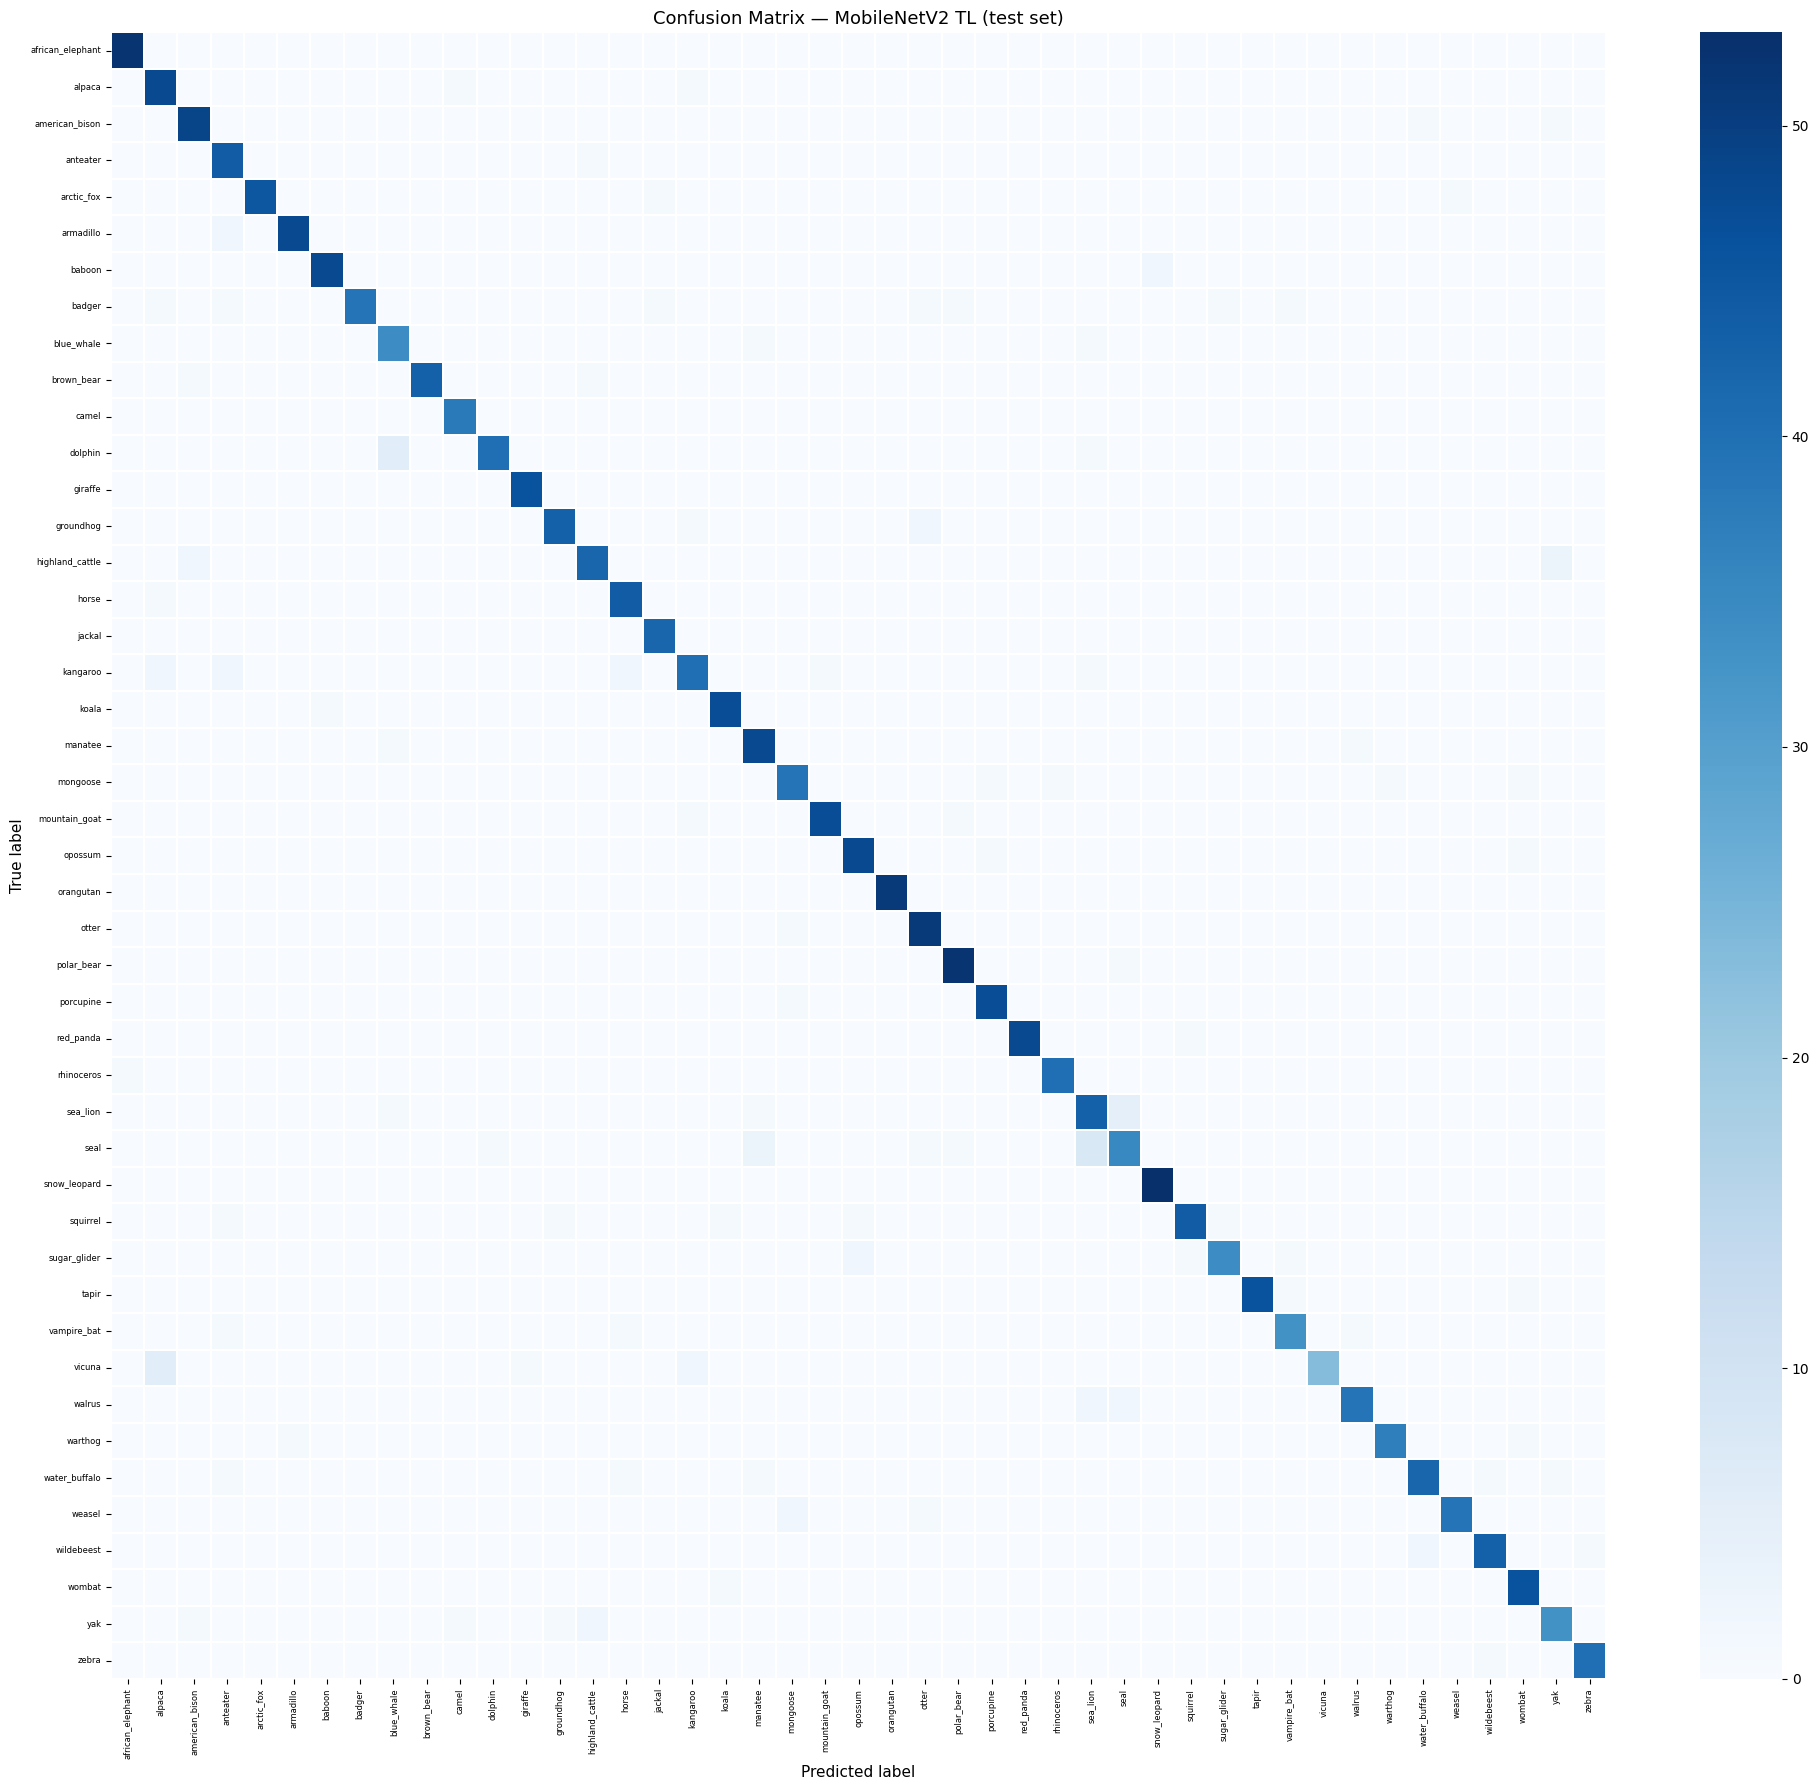

In [ ]:
def plot_confusion_matrix(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    class_names: list,
    model_name: str,
) -> np.ndarray:
    """
    Plot a full 45x45 confusion matrix as a seaborn heatmap.

    Parameters
    ----------
    y_true : np.ndarray
        Ground-truth labels.
    y_pred : np.ndarray
        Predicted labels.
    class_names : list of str
        Class name strings in index order.
    model_name : str
        Used in the chart title.

    Returns
    -------
    np.ndarray
        The raw confusion matrix array (shape: num_classes x num_classes).
    """
    conf_matrix = confusion_matrix(y_true, y_pred)
    fig, ax     = plt.subplots(figsize=(20, 18))
    sns.heatmap(
        conf_matrix,
        annot=False,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names,
        ax=ax,
        linewidths=0.2,
    )
    ax.set_xlabel('Predicted label', fontsize=11)
    ax.set_ylabel('True label',      fontsize=11)
    ax.set_title(f'Confusion Matrix — {model_name} (test set)', fontsize=13)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=6)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0,  fontsize=6)
    plt.tight_layout()
    plt.show()
    return conf_matrix


# ── 5.4  Confusion matrix
conf_matrix = plot_confusion_matrix(y_true, y_pred_tl, class_names, 'MobileNetV2 TL')

**Confusion matrix interpretation:** The correct predictions are the bright cells along the diagonal. The other cells which are bright present in off-diagonal represents some confusion between the specific class pairs this can be coat patterns and body proportions.  




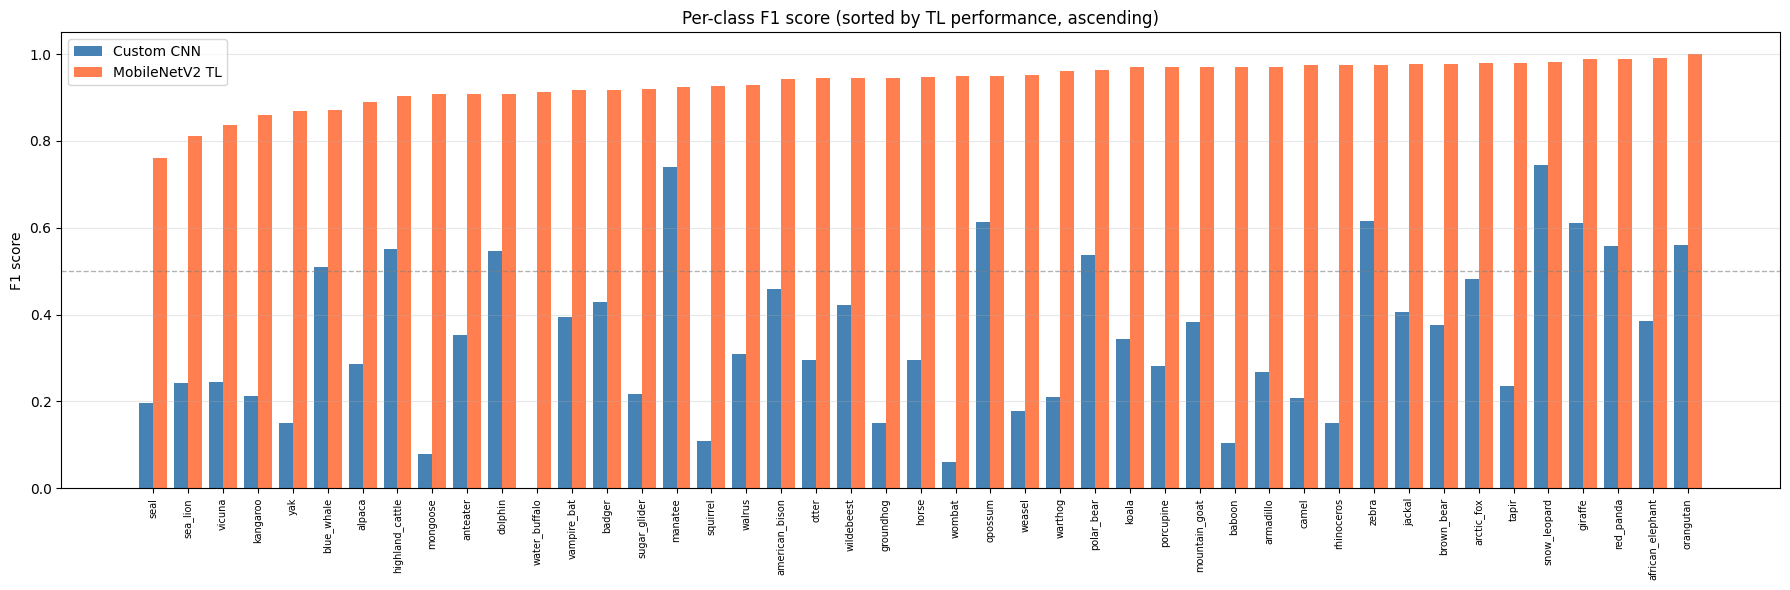

In [ ]:
def plot_per_class_f1(
    y_true: np.ndarray,
    y_pred_cnn: np.ndarray,
    y_pred_tl: np.ndarray,
    class_names: list,
) -> tuple:
    """
    Plot a side-by-side bar chart of per-class F1 scores for both models.

    Classes are sorted in ascending order of the TL model's F1 score so
    the worst-performing classes appear on the left.

    Parameters
    ----------
    y_true : np.ndarray
        Ground-truth labels.
    y_pred_cnn : np.ndarray
        Custom CNN predicted labels.
    y_pred_tl : np.ndarray
        Transfer learning predicted labels.
    class_names : list of str
        Class names in index order.

    Returns
    -------
    tuple of (np.ndarray, np.ndarray)
        f1_per_class_cnn, f1_per_class_tl — per-class F1 arrays.
    """
    f1_per_class_cnn = f1_score(y_true, y_pred_cnn, average=None, zero_division=0)
    f1_per_class_tl  = f1_score(y_true, y_pred_tl,  average=None, zero_division=0)
    sorted_order     = np.argsort(f1_per_class_tl)
    sorted_labels    = [class_names[i] for i in sorted_order]

    x_positions = np.arange(len(class_names))
    fig, ax     = plt.subplots(figsize=(18, 6))
    ax.bar(x_positions - 0.2, f1_per_class_cnn[sorted_order], width=0.4,
           label='Custom CNN',     color='steelblue')
    ax.bar(x_positions + 0.2, f1_per_class_tl[sorted_order],  width=0.4,
           label='MobileNetV2 TL', color='coral')
    ax.set_xticks(x_positions)
    ax.set_xticklabels(sorted_labels, rotation=90, fontsize=7)
    ax.set_ylabel('F1 score')
    ax.set_title('Per-class F1 score (sorted by TL performance, ascending)')
    ax.axhline(0.5, color='gray', linestyle='--', alpha=0.6, linewidth=1)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
    return f1_per_class_cnn, f1_per_class_tl


# ── 5.5  Per-class F1
f1_per_class_cnn, f1_per_class_tl = plot_per_class_f1(
    y_true, y_pred_cnn, y_pred_tl, class_names
)

**Per-class F1 observation:** The hardest classes are those on the left with almost nil F1; these are usually species that are visually similar to others or minority classes with limited training images. In nearly every class, the TL model consistently performs better than the CNN, demonstrating that ImageNet pre-training yields truly valuable animal traits.

In [ ]:
def print_top_confused_pairs(
    conf_matrix: np.ndarray,
    class_names: list,
    top_n: int = 10,
) -> None:
    """
    Print the top N most confused class pairs from a confusion matrix.

    The diagonal (correct predictions) is zeroed out so only misclassifications
    are ranked. Results are printed as 'True → Predicted : count'.

    Parameters
    ----------
    conf_matrix : np.ndarray
        Square confusion matrix of shape (num_classes, num_classes).
    class_names : list of str
        Class names in index order.
    top_n : int, optional
        Number of confused pairs to display. Default is 10.

    Returns
    -------
    None
    """
    conf_no_diag = conf_matrix.copy()
    np.fill_diagonal(conf_no_diag, 0)

    flat_sorted_idx  = np.argsort(conf_no_diag.ravel())[::-1][:top_n]
    row_indices, col_indices = np.unravel_index(flat_sorted_idx, conf_matrix.shape)

    print(f'Top-{top_n} confused class pairs (true → predicted):')
    print(f'{"True":<25} {"Predicted":<25} {"Count":>6}')
    print('-' * 60)
    for row_idx, col_idx in zip(row_indices, col_indices):
        print(
            f'{class_names[row_idx]:<25}'
            f'{class_names[col_idx]:<25}'
            f'{conf_no_diag[row_idx, col_idx]:>6}'
        )


# ── 5.6  Top confused pairs
print_top_confused_pairs(conf_matrix, class_names, top_n=10)

Top-10 confused class pairs (true → predicted):
True                      Predicted                  Count
------------------------------------------------------------
seal                     sea_lion                      8
dolphin                  blue_whale                    6
vicuna                   alpaca                        6
sea_lion                 seal                          5
seal                     manatee                       3
highland_cattle          yak                           3
sugar_glider             opossum                       2
walrus                   sea_lion                      2
baboon                   snow_leopard                  2
kangaroo                 horse                         2


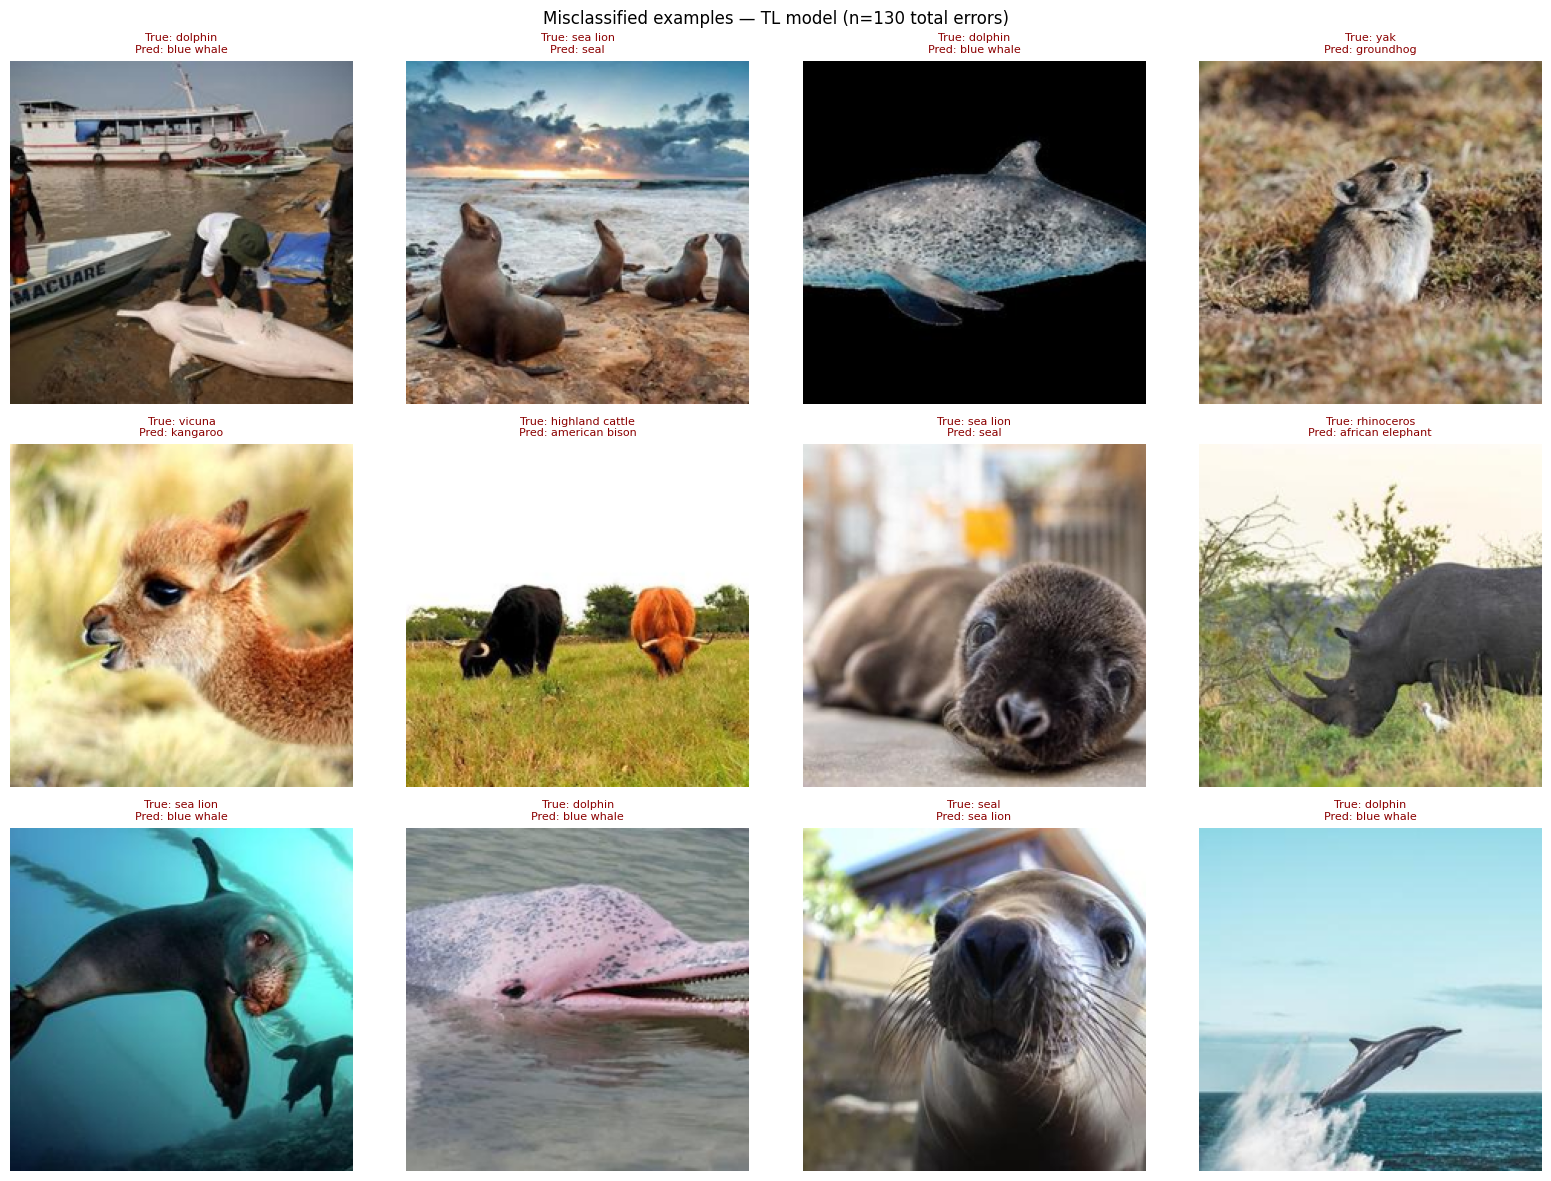

Error count : 130 / 2063 (6.3%)


In [ ]:
def plot_misclassified_examples(
    x_test: np.ndarray,
    y_test: np.ndarray,
    y_pred: np.ndarray,
    class_names: list,
    img_size: tuple,
    n_examples: int = 12,
) -> None:
    """
    Display a grid of randomly selected misclassified test images.

    Each cell shows the image alongside its true and predicted class labels.
    This qualitative analysis reveals whether errors stem from visual similarity,
    image quality issues, or atypical poses.

    Parameters
    ----------
    x_test : np.ndarray
        1-D array of test image file path strings.
    y_test : np.ndarray
        Ground-truth integer labels for test set.
    y_pred : np.ndarray
        Predicted integer labels.
    class_names : list of str
        Class name strings in index order.
    img_size : tuple of (int, int)
        Display resize (height, width).
    n_examples : int, optional
        Number of misclassified images to show. Default is 12.

    Returns
    -------
    None
    """
    error_indices = [
        idx for idx in range(len(y_test))
        if y_test[idx] != y_pred[idx]
    ]
    random.shuffle(error_indices)
    selected_indices = error_indices[:n_examples]

    n_cols = 4
    n_rows = (n_examples + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 4))

    for ax, error_idx in zip(axes.flat, selected_indices):
        try:
            img = PIL.Image.open(x_test[error_idx]).convert('RGB').resize(img_size)
            ax.imshow(img)
        except Exception:
            pass
        true_name = class_names[y_test[error_idx]].replace('_', ' ')
        pred_name = class_names[y_pred[error_idx]].replace('_', ' ')
        ax.set_title(f'True: {true_name}\nPred: {pred_name}', fontsize=8, color='darkred')
        ax.axis('off')

    for ax in axes.flat[len(selected_indices):]:
        ax.axis('off')

    plt.suptitle(f'Misclassified examples — TL model (n={len(error_indices)} total errors)', fontsize=12)
    plt.tight_layout()
    plt.show()
    error_rate = len(error_indices) / len(y_test)
    print(f'Error count : {len(error_indices)} / {len(y_test)} ({error_rate * 100:.1f}%)')


# ── 5.7  Misclassified examples
plot_misclassified_examples(x_test, y_test, y_pred_tl, class_names, img_size_tl)

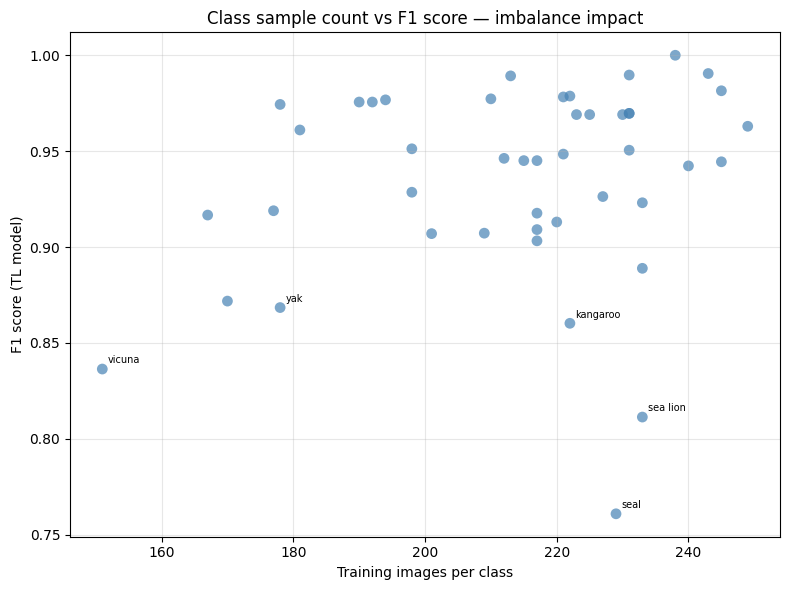

Pearson r (sample count vs F1) = 0.218
A positive r confirms: more training images -> higher F1.


In [ ]:
def plot_imbalance_vs_f1(
    y_train: np.ndarray,
    f1_per_class: np.ndarray,
    class_names: list,
    num_classes: int,
    n_annotate: int = 5,
) -> None:
    """
    Scatter plot of per-class training sample count vs per-class F1 score.

    Reveals whether class imbalance is a significant driver of model errors.
    A positive Pearson correlation confirms that minority classes are harder
    to classify. The n_annotate worst-performing classes are labelled.

    Parameters
    ----------
    y_train : np.ndarray
        Integer training labels.
    f1_per_class : np.ndarray
        Per-class F1 scores (shape: num_classes).
    class_names : list of str
        Class name strings in index order.
    num_classes : int
        Total number of classes.
    n_annotate : int, optional
        Number of worst classes to annotate on the plot. Default is 5.

    Returns
    -------
    None
    """
    training_counts = np.bincount(y_train, minlength=num_classes)
    worst_class_idx = np.argsort(f1_per_class)[:n_annotate]

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(
        training_counts, f1_per_class,
        alpha=0.7, s=60, color='steelblue', edgecolors='none',
    )
    for class_idx in worst_class_idx:
        ax.annotate(
            class_names[class_idx].replace('_', ' '),
            xy=(training_counts[class_idx], f1_per_class[class_idx]),
            xytext=(4, 4), textcoords='offset points', fontsize=7,
        )
    ax.set_xlabel('Training images per class')
    ax.set_ylabel('F1 score (TL model)')
    ax.set_title('Class sample count vs F1 score — imbalance impact')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    pearson_r = np.corrcoef(training_counts, f1_per_class)[0, 1]
    print(f'Pearson r (sample count vs F1) = {pearson_r:.3f}')
    print('A positive r confirms: more training images -> higher F1.')


# ── 5.8  Imbalance vs F1
plot_imbalance_vs_f1(y_train, f1_per_class_tl, class_names, num_classes)

**Error analysis summary:**
1. Transfer learning is clearly superior - MobileNetV2 is being pre-trained on ImageNet which provides rich animal features that transfer directly, far exceeding a scratch CNN trained on ~4400 images.
2. Class imbalance is the primary error driver - Between the training set size and F1. There is a positive pearsons correlation which is confirmed by scatter plot.
3. Visually similar species cause most confusions - The top confused pairs between coat patterns and boby proportion are the challenges in fine-grained classification.
4. Custom CNN is a reasonable baseline - At this dataset scale it learns meaningful features from scratch but it cannot match MobileNetV2.
5. Potential improvements - Test-time augmentation (TTA), a larger backbone like EfficientNetB3, focal loss to penalize simple majority-class examples more, or Grad-CAM heatmaps to confirm the model focuses on the animal rather than the background.



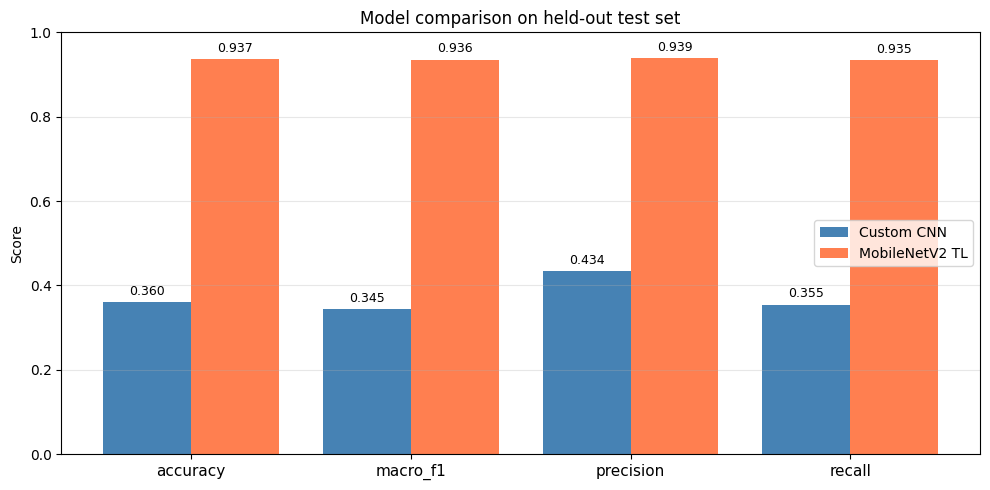

In [ ]:
def plot_model_comparison(
    metrics_cnn: dict,
    metrics_tl: dict,
    metric_keys: list = None,
) -> None:
    """
    Plot a grouped bar chart comparing scalar metrics for both models.

    Parameters
    ----------
    metrics_cnn : dict
        Metrics dict returned by compute_and_print_metrics() for the CNN.
    metrics_tl : dict
        Metrics dict returned by compute_and_print_metrics() for the TL model.
    metric_keys : list of str, optional
        Which metric keys to plot. Defaults to accuracy, macro_f1, precision, recall.

    Returns
    -------
    None
    """
    if metric_keys is None:
        metric_keys = ['accuracy', 'macro_f1', 'precision', 'recall']

    cnn_values  = [metrics_cnn[key] for key in metric_keys]
    tl_values   = [metrics_tl[key]  for key in metric_keys]
    x_positions = np.arange(len(metric_keys))

    fig, ax = plt.subplots(figsize=(10, 5))
    cnn_bars = ax.bar(x_positions - 0.2, cnn_values, width=0.4,
                      label='Custom CNN',     color='steelblue')
    tl_bars  = ax.bar(x_positions + 0.2, tl_values,  width=0.4,
                      label='MobileNetV2 TL', color='coral')

    ax.set_xticks(x_positions)
    ax.set_xticklabels(metric_keys, fontsize=11)
    ax.set_ylim(0, 1)
    ax.set_ylabel('Score')
    ax.set_title('Model comparison on held-out test set', fontsize=12)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

    for bar in list(cnn_bars) + list(tl_bars):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=9,
        )

    plt.tight_layout()
    plt.show()


# ── 5.9  Model comparison chart
plot_model_comparison(metrics_cnn, metrics_tl)

---
## Section 6 · Reproducibility and Code Quality

In [ ]:
def print_reproducibility_report(seed: int) -> None:
    """
    Print a complete environment and seed report for reproducibility.

    Documents all library versions and confirms that every relevant
    random number generator was seeded before the experiment began.

    Parameters
    ----------
    seed : int
        The global random seed used throughout the notebook.

    Returns
    -------
    None
    """
    import sklearn
    import matplotlib
    import seaborn

    print('=== Reproducibility Report ===')
    print(f'Global seed          : {seed}')
    print(f'Python               : {sys.version}')
    print(f'Platform             : {platform.platform()}')
    print(f'TensorFlow           : {tf.__version__}')
    print(f'Keras                : {keras.__version__}')
    print(f'NumPy                : {np.__version__}')
    print(f'pandas               : {pd.__version__}')
    print(f'scikit-learn         : {sklearn.__version__}')
    print(f'matplotlib           : {matplotlib.__version__}')
    print(f'seaborn              : {seaborn.__version__}')
    print('\nSeeds applied (in order):')
    print(f'  os.environ[PYTHONHASHSEED] = {seed}')
    print(f'  random.seed({seed})')
    print(f'  np.random.seed({seed})')
    print(f'  tf.random.set_seed({seed})')
    print(f'  train_test_split(random_state={seed})')


# ── 6.1  Environment report
print_reproducibility_report(SEED)

=== Reproducibility Report ===
Global seed          : 42
Python               : 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Platform             : Linux-6.6.113+-x86_64-with-glibc2.35
TensorFlow           : 2.19.0
Keras                : 3.13.2
NumPy                : 2.0.2
pandas               : 2.2.2
scikit-learn         : 1.6.1
matplotlib           : 3.10.0
seaborn              : 0.13.2

Seeds applied (in order):
  os.environ[PYTHONHASHSEED] = 42
  random.seed(42)
  np.random.seed(42)
  tf.random.set_seed(42)
  train_test_split(random_state=42)


In [ ]:
def save_models(cnn_model: keras.Model, tl_model: keras.Model) -> None:
    """
    Save both trained models to disk in the native Keras format.

    The .keras format stores the full model (architecture + weights +
    optimiser state) and is the recommended format for TensorFlow 2.x.

    Parameters
    ----------
    cnn_model : keras.Model
        Trained Custom CNN.
    tl_model : keras.Model
        Trained MobileNetV2 transfer learning model.

    Returns
    -------
    None
    """
    cnn_save_path = 'custom_cnn_final.keras'
    tl_save_path  = 'mobilenetv2_tl_final.keras'
    cnn_model.save(cnn_save_path)
    tl_model.save(tl_save_path)
    print(f'Saved: {cnn_save_path}')
    print(f'Saved: {tl_save_path}')


# ── 6.2  Save both models
save_models(cnn_model, tl_model)

Saved: custom_cnn_final.keras
Saved: mobilenetv2_tl_final.keras


In [ ]:
def verify_model_serialisation(
    original_model: keras.Model,
    saved_path: str,
    test_dataset: tf.data.Dataset,
    tolerance: float = 1e-5,
) -> bool:
    """
    Reload a saved model and verify its predictions match the original.

    Runs one batch through both the original and the reloaded model and
    checks that the maximum absolute difference in softmax outputs is
    below the specified tolerance.

    Parameters
    ----------
    original_model : keras.Model
        The model that was saved.
    saved_path : str
        File path of the saved model.
    test_dataset : tf.data.Dataset
        Dataset to draw a single batch from for comparison.
    tolerance : float, optional
        Maximum acceptable absolute difference. Default is 1e-5.

    Returns
    -------
    bool
        True if predictions match within tolerance; False otherwise.
    """
    reloaded_model = keras.models.load_model(saved_path)
    for image_batch, _ in test_dataset.take(1):
        original_probs  = original_model.predict(image_batch,  verbose=0)
        reloaded_probs  = reloaded_model.predict(image_batch, verbose=0)
        max_difference  = np.max(np.abs(original_probs - reloaded_probs))
        passed          = max_difference < tolerance
        status_label    = 'PASS' if passed else 'FAIL'
        print(f'{saved_path:<40} max diff: {max_difference:.2e}  [{status_label}]')
        return passed


# ── 6.3  Verify saved models
verify_model_serialisation(cnn_model, 'custom_cnn_final.keras',    test_dataset_cnn)
verify_model_serialisation(tl_model,  'mobilenetv2_tl_final.keras', test_dataset_tl)

custom_cnn_final.keras                   max diff: 0.00e+00  [PASS]
mobilenetv2_tl_final.keras               max diff: 0.00e+00  [PASS]


np.True_

In [ ]:
def print_hyperparameter_table(
    img_size_cnn: tuple,
    img_size_tl: tuple,
    batch_size: int,
    epochs_cnn: int,
    epochs_tl_head: int,
    epochs_tl_fine: int,
    lr_cnn: float,
    lr_tl_head: float,
    lr_tl_fine: float,
    dropout_cnn: float,
    dropout_tl: float,
    val_split: float,
    test_split: float,
    seed: int,
) -> None:
    """
    Print all hyper-parameters alongside their design rationale.

    Provides a single reference table showing every tunable value used
    in the experiment, making the notebook fully self-documenting.

    Parameters
    ----------
    (All parameters match the notebook-level config constants.)

    Returns
    -------
    None
    """
    hyper_param_df = pd.DataFrame({
        'Parameter': [
            'SEED', 'img_size_cnn', 'img_size_tl', 'batch_size',
            'epochs_cnn', 'epochs_tl_head', 'epochs_tl_fine',
            'lr_cnn', 'lr_tl_head', 'lr_tl_fine',
            'dropout_cnn', 'dropout_tl', 'val_split', 'test_split',
        ],
        'Value': [
            seed, str(img_size_cnn), str(img_size_tl), batch_size,
            epochs_cnn, epochs_tl_head, epochs_tl_fine,
            lr_cnn, lr_tl_head, lr_tl_fine,
            dropout_cnn, dropout_tl, f'{val_split * 100:.0f}%', f'{test_split * 100:.0f}%',
        ],
        'Rationale': [
            'Standard reproducibility seed',
            'Faster training from scratch (vs 224)',
            'MobileNetV2 recommended input size',
            'Fits Colab T4 GPU memory',
            'Upper bound — EarlyStopping decides actual stop',
            'Enough epochs for head to converge on frozen base',
            'Short — already warm-started from Stage 1',
            'Stable for scratch CNN (1e-3 caused gradient instability)',
            'Standard Adam LR for head-only training',
            'Very small — prevents catastrophic forgetting of ImageNet features',
            'Moderate — no L2; BatchNorm provides implicit regularisation',
            'Slightly higher — MobileNetV2 base already regularises features',
            'Stratified — preserves class proportions in validation set',
            'Stratified — held-out; never used during training or tuning',
        ],
    })
    print(hyper_param_df.to_string(index=False))


# ── 6.4  Hyper-parameter table
print_hyperparameter_table(
    img_size_cnn, img_size_tl, batch_size,
    epochs_cnn, epochs_tl_head, epochs_tl_fine,
    lr_cnn, lr_tl_head, lr_tl_fine,
    dropout_cnn, dropout_tl, val_split, test_split, SEED,
)

     Parameter      Value                                                          Rationale
          SEED         42                                      Standard reproducibility seed
  img_size_cnn (128, 128)                              Faster training from scratch (vs 224)
   img_size_tl (224, 224)                                 MobileNetV2 recommended input size
    batch_size         32                                           Fits Colab T4 GPU memory
    epochs_cnn         60                    Upper bound — EarlyStopping decides actual stop
epochs_tl_head         25                  Enough epochs for head to converge on frozen base
epochs_tl_fine         25                          Short — already warm-started from Stage 1
        lr_cnn     0.0003          Stable for scratch CNN (1e-3 caused gradient instability)
    lr_tl_head      0.001                            Standard Adam LR for head-only training
    lr_tl_fine    0.00005 Very small — prevents catastrophic forgettin

# SUMMARY

From all the analysis done, we encourage to use transfer learning model over scratch models, as we can see MobileNetV2 achieved 93.6% validation accuracy compared to a scratch CNN, which only achieved 36.02%.
Because they continuously received lower F1 scores in the evaluation, concentrate on interventions for minority species classes that have previously performed badly due to a lack of training images.
Since the CNN with 1.2 million parameters overfitted badly with just 306 images per class and a 21.61% train-val gap, encourage a good balance between model complexity and available data.
To further reduce the performance difference for underrepresented classes, more study on sophisticated regularization strategies like Mixup augmentation and Focal loss could be required.